실습 환경 준비

In [ ]:
%pip install sentence-transformers scikit-learn matplotlib
#sentence-transformers: 미리 학습된 sentence-transformers 모델을 불러와 encode로 문장 임베딩을 만들 수 있음.
# scikit-learn의 cosine_similarity는 정규화된 벡터의 내적 기반 유사도를 계산하고, PCA는 데이터를 낮은 차원으로 줄여 시각화할 때 자주 씀.

## 개념

임베딩은 **텍스트를 숫자 벡터로 바꾸는 방법**  
컴퓨터는 문장의 뜻을 직접 이해하지 못하므로, 문장을 숫자 형태로 바꾸어 계산할 수 있도록 해야 합니다.

임베딩에서는 다음 개념이 중요

### 1.의미가 비슷하면 벡터도 가깝다
예를 들어 아래 두 문장은 표현은 조금 다르지만 의미가 비슷합니다.

- 오늘 날씨가 맑다.
- 하늘이 매우 화창하다.

이런 문장들은 임베딩 공간에서도 가까운 위치에 놓이는 것이 이상적.

### 2. 의미가 다르면 벡터도 멀다
예를 들어 아래 문장은 앞의 날씨 문장들과 주제가 다름.

- 나는 점심으로 김치찌개를 먹었다.

이 문장은 날씨에 관한 문장들과 비교했을 때 더 멀리 떨어져야 함.

### 3. 임베딩은 활용이 목적이다
임베딩은 단순히 숫자를 만드는 기술이 아니라, 다음과 같은 작업을 하기 위해 사용됩니다.

- 의미 기반 검색
- 문장 유사도 비교
- 문서 추천
- 텍스트 분류
- 군집화
- RAG 검색

예를 들어 "cat", "dog", "apple"은 사람에게는 의미가 있지만, 컴퓨터에게는 그냥 문자

- 가장 단순한 방법은
 - cat -> 1
 - dog -> 2
 - apple -> 3

이렇게 하면 cat과 dog가 비슷하다는 정보가 전혀 없음.

그래서 단어를 숫자 벡터로 바꾸되, 비슷한 의미의 단어가 벡토 공간에서도 가까워지게 만드는 것이 임베딩의 핵심

# 1. One-hot encoding

예를 들면, 단어 집합이 5개면:

- cat -> [1,0,0,0,0]
- dog -> [0,1,0,0,0]

이 방식은 간단하지만, 모든 단어가 서로 똑같이 멀다.

cat과 dog도, cat과 table도 거리상 비슷하게 취급됨.



In [ ]:
import pandas as pd #데이터 처리용 분석 라이브러리
import numpy as np #선형 대수학 분석 라이브러리

# 1. 샘플 데이터 생성
data = {'과일': ['사과', '바나나', '딸기', '사과', '딸기']}
df = pd.DataFrame(data)

# 2. 원-핫 인코딩 적용 (dtype=int를 추가하면 0, 1로 나옵니다)
one_hot_df = pd.get_dummies(df, columns=['과일'], dtype=int)

# 3. 행렬(Matrix) 형태로 변환
matrix = one_hot_df.values

print("--- 원본 데이터프레임 ---")
print(df)
print("\n--- 원-핫 인코딩 데이터프레임 ---")
print(one_hot_df)
print("\n--- 최종 행렬 (Matrix) ---")
print(matrix)

In [ ]:
import numpy as np
items = np.array(['사과', '바나나', '딸기', '사과', '딸기'])
items.shape # (5, ) -> 공간을 마련해둠. -> 1차원 (Vector)
#2차원으로 바꾸기 위해주기 위해서는 
items = items.reshape(-1, 1) # -1은 약수개의 shape으로 바뀜

In [ ]:
import numpy as np
A = np.array([1,2,3,4,5,6]) # 1x6 -> 2x3,3x2
# -1을 넣으면, NumPy가 전체 요소 개수에 맞춰서 남은 한 자리를 자동으로 계산
A.reshape(-1,3) # 열은 3개로 고정하고, 행은 알아서 계산해
A.reshape(3,-1) # 행은 3개로 고정하고, 열은 알아서 계산해
A.reshape(-1,2) # 열을 2개로 맞춥니다. 6 / 2 = 3이므로 행은 자동으로 3이 됩니다.
A.reshape(2,-1)
A.shape

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# sklearn - 머신러닝 분석용 라이브러리 (사이킷런)
import numpy as np

# 데이터 준비 (2차원 배열 형태여야 함)
items = np.array(['사과', '바나나', '딸기', '사과', '딸기']).reshape(-1, 1)

# Encoder 객체 생성 및 변환
encoder = OneHotEncoder(sparse_output=False) # 결과를 밀집 행렬(numpy)로 반환
one_hot_encoded = encoder.fit_transform(items)

# 결과 확인
print("카테고리 목록:", encoder.categories_)
print("\n인코딩 결과:")
print(one_hot_encoded)

# 2. Count / co-occurrence 기반

어떤 단어가 주변에서 자주 같이 나타나는지를 세어서 벡터를 만드는 방식.

이 계열의 대표적인 후속 정리형 방법이 **GloVe**.

**GloVe**는 말뭉치 전체의 공동 출현(동시 출현)(co-occureence) 통계를 비지도 학습 알고리즘이다.

이 방식은 의미를 어느 정도 반영하지만, 벡터가 매우 크고 희소해지기 쉽고 학습/저장이 비효율적일 수 있음.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. 샘플 코퍼스(말뭉치)
corpus = [
    "I like apple",
    "I like banana",
    "I enjoy apple"
]

# 2. CountVectorizer로 단어 빈도 추출
# 단어 단위로 쪼개기 위해 tokenizer 설정 (기본은 2글자 이상만 인식)
vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X = vectorizer.fit_transform(corpus)

# 3. 단어 목록 확인
words = vectorizer.get_feature_names_out()

# 4. 공출현 행렬 계산 (Matrix Multiplication: X.T * X)
# 행렬 곱을 통해 단어 간의 동시 출현 빈도를 계산합니다.
co_occurrence_matrix = (X.T * X)
# 행렬은 보통 대문자를 많이 사용하고 벡터는 소문자로 많이 사용함

# 자기 자신과의 공출현(대각선)을 0으로 처리 (선택 사항)
co_occurrence_matrix.setdiag(0)

# 5. DataFrame으로 시각화
df_matrix = pd.DataFrame(
    co_occurrence_matrix.toarray(),
    index=words,
    columns=words
)

print("단어 목록:", words)
print("\n--- 공출현 행렬 (Co-occurrence Matrix) ---")
print(df_matrix)

카운트 기반 방식은 단어 빈도수만 고려하기 때문에 'the', 'a' 같은 의미 없는 고빈도 단어가 높은 점수를 받는 단점이 있습니다. 이를 해결하기 위해 보통 다음 단계로 넘어감.

- PPMI (Positive Pointwise Mutual Information): 단순히 많이 나온 게 아니라, "얼마나 의외로 같이 나왔는가"를 계산하여 가중치를 조절합니다.

- SVD (특이값 분해): 너무 큰 행렬의 크기를 줄여 핵심 의미만 추출합니다.

1. 코사인 유사도(Cosine Similarity) 계산

단어 벡터(행렬의 각 행) 사이의 각도를 측정하여 유사도를 구함. 값이 1에 가까울수록 의미가 유사하고, 0에 가까울수록 관련이 없음을 뜻함.

<img src='https://lh5.googleusercontent.com/proxy/FfGYk0hn_yLUxwRuGrTMcYh4d_d_cjyt8i5tR673HVQ152pERKQalsjLcWMcsIEkIhAfQ_qUjbaVyhSHAt6xFt75j8lNqd0_56g9XpoFGatqDUg2f7N7'>

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 앞서 만든 df_matrix를 사용합니다.
# 'apple'과 'banana'의 유사도 계산
apple_vec = df_matrix.loc[['apple']].values
banana_vec = df_matrix.loc[['banana']].values

similarity = cosine_similarity(apple_vec, banana_vec)

print(f"apple과 banana의 코사인 유사도: {similarity[0][0]:.4f}")

# 전체 단어 간 유사도 행렬 출력
sim_df = pd.DataFrame(cosine_similarity(df_matrix), index=words, columns=words)
print("\n--- 단어 유사도 행렬 ---")
print(sim_df)

In [ ]:
A = [3,4,2,1,4]
print(A.sort()) # print문을 했을 때 Noned이 나옴
A # 원본을 건드림. (얕은 복사)

sorted(A) #return -> print문 줌. / 원본이 바뀌지 않음(깊은 복사)

In [ ]:
import numpy as np
import pandas as pd

# 1. 샘플 데이터 (말뭉치)
# 각 리스트 요소의 하나의 '문서'로 생각.
corpus = ["I like apple", "I like banana", "I enjoy apple"]

# 2. 모든 고유 단어 추출
## 모든 문장을 합치고 소문자로 변환 후 공백으로 나누어 단어 리스트 생성
# 1) " ".join(corpus) -> 모든 문장을 하나로 합침: 'I like apple I like banana I enjoy apple'
# 2) .lower.split() -> 소문자로 바꾸고 공백 기준으로 단어를 자름(리스트화)
# 3) set(...): 중복된 단어를 제거하여 유일한 단어만 남김.
# 4) sorted(...): 단어들을 가나다(알파벳) 순으로 정렬하여 일관된 인덱스 부여
words = sorted(list(set(" ".join(corpus).lower().split())))

# 3. 단어-문장 행렬(Word-Document Matrix) 생성
# 행(index)은 우리가 뽑은 '고유 단어', 옅은 '각 문서 번호'인 빈 표 (0으로 채워짐)
word_doc_matrix = pd.DataFrame(0,index=words,columns=[f"Doc{i}" for i in range(len(corpus))])

#원본 문장을 하나씩 순회하며, 단어 출현 여부를 1로 기록함.
for i,sentence in enumerate(corpus):
    sentence_words = sentence.lower().split()
    for word in sentence_words:
        # 특정 단어(행)가 해당 문서(열)에 존재하면 0을 1로 변경(Binary Vector)
        word_doc_matrix.loc[word,f"Doc{i}"] = 1
print("[1] 단어-문장 행렬(1:포함, 0:미포함")
print(word_doc_matrix)
print('---'*50)

import math
# 코사인 유사도 함수 정의 (A와 B의 내적 / A의 크기 * B의 크기)
def get_cosine_similarity(v1,v2):
    #분자 : 내적: 같은 위치의 원소끼리 곱한 뒤 더함.
    #zip(v1, v2)는 두 벡터의 요소를 짝지어줌 ex)(0,0),(1,1),(0,1)...)
    dot_product = sum(a*b for a,b in zip(v1,v2))

    #분모: 벡터의 크기 (norm) -> 각 원소를 제곱해서 더한 뒤 루트를 씌움
    norm1 = math.sqrt(sum(a**2 for a in v1))
    norm2 = math.sqrt(sum(b**2 for b in v2))

    #분모가 0인 경우 (단어가 한 번도 등장하지 않은 경우) -> 오류 방지
    if norm1 ==0  or norm2 ==0:
        return 0.0
    #최종 유사도 반환 (0~1, 1에 가까울수록 문맥이 비슷합)
    return dot_product / (norm1 * norm2)

# 모든 쌍에 대한 유사도 계산
similarity_df = pd.DataFrame(index=words, columns = words)

#이중 반복문을 통해 '모든 단어'와 '모든 단어'를 하나씩 대조함.
for row_word in words:
    for col_word in words:
        # 단어-문장 행렬에서 해당 단어가 각 문서에 나타난 패턴(벡터)를 추출
        # .values를 써서 Pandas 형태가 아닌 순수 숫자 패턴(Numpy)로 가져옴
        v1 = word_doc_matrix.loc[row_word].values
        v2 = word_doc_matrix.loc[col_word].values

        # 유사도 계산 후 저장
        ## 미리 정의한 함수에 두 벡터에 넣어 유사도 점수를 얻고 기록함.
        similarity_df.loc[row_word,col_word] = get_cosine_similarity(v1,v2)

print("2. 단어간 코사인 유사도 결과")
# 계산 결과는 Object 타입으므로 float(실수)로 변환하 소수점 2자리 반올림
print(similarity_df.astype(float).round(2))

**PPMI(Postive Pointwise Mutual Information) 계산**

단순 카운트 방식은 'the','a','i' 같이 자주 등장하는 단어가 모든 든어와 연관성이 높게 나오는 단점이 있음.

PPMI는 "두 단어가 함께 나올 확률"을 "각자 나올 확률"로 나누어, **정말로 의미 있게 자주 같이 나오는 지**를 계산

$$
PPMI(x,y) = max(0, log_2 {\frac{P(x,y)}{P(x)P(y)}})
$$

1. 왜 log를 사용할까?
곱이 합으로 바뀌어서

2. 왜 log2일까?
log2는 비트 연산자때문에 빠르게 계산하기 위해서

$log(AB) = log(A)+log(B)$

$\log \dfrac{A}{B} = log(A) - log(B)$

$log$는 사칙연산에 대한 연산량을 줄여줌.

1. A열이 있을 때, 각각 데이터가 너무 큰 경우는 어떻게 처리하는 게 좋나?
-> 각각 무슨 의미가 있나? A1: 100, A2: 100000, A3: 10000000
-> log 사용
반대로 너무 작은 경우는 e사용 $e^x$

2. A열과 B라는 열이 있다.
-> A1: 100, A2: 100000, A3: 10000000 / B1: 0.3,0.35, 0.24
-> 정규화 (Normalization), 표준화

표준정규분호
-> 정규분포가 있다면 표준화를 통해 만드는 것.

$$
Z = {\frac {X-\mu}{\sigma}}
$$


In [ ]:
import numpy as np

def calculate_ppmi(C, verbose=False):
    # C: 공출현 행렬 (numpy array)
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C) # 전체 공출현 횟수
    S = np.sum(C, axis=0) # 각 단어별 등장 횟수 합

    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            # p(x,y) / (p(x) * p(y)) = (C(x,y)/N) / (S(x)/N * S(y)/N) = C(x,y) * N / (S(x) * S(y))
            pmi = np.log2(C[i, j] * N / (S[i] * S[j]) + 1e-8) # 1e-8은 log(0) 방지용
            M[i, j] = max(0, pmi)

    return M

# 공출현 행렬 데이터 준비 (앞의 co_occurrence_matrix 활용)
C = co_occurrence_matrix.toarray()
W = calculate_ppmi(C)

# 결과 출력
ppmi_df = pd.DataFrame(W, index=words, columns=words)
print("--- PPMI 행렬 ---")
print(ppmi_df.round(3))

| 구분 | 목적 | 특징 |
| :--- | :--- | :--- |
| **코사인 유사도** | 두 단어 벡터가 얼마나 닮았는가? | 벡터의 크기보다 **방향(각도)**을 중시함 |
| **PPMI** | 두 단어의 결합이 우연인가, 필연인가? | **고빈도 단어**의 노이즈를 줄여줌 |

## 3. Word2Vec

단어 자체를 직업 의미 공간으로 매핑하는 저차원 밀집 벡터(dense vector)를 학습하는 방법

**비슷한 문맥에서 등장하는 단어는 비슷한 의미를 가진다.**

예를 들어,
- "고양이가 소파 위에서 잔다."
- "강아지가 소파 위에서 잔다."

이런 문장을 많이 보면, "고양이"와 "강아지"는 비슷한 주변 단어와 함께 등장하므로 비슷한 벡터를 가지게 됨.

**사전적 정의**로 배우는 것이 아니라, **문맥 패턴**으로 배움

<img src='https://towardsdatascience.com/wp-content/uploads/2021/03/15F4TXdFYwqi-BWTToQPIfg.jpeg'>

두 가지 구조를 제안

- CBOW(Continuous Bag of Words)
    - 주변 단어들로 중심 단어를 예측

        ex) I drink cold water every day

        중심 단어가 water이고 window 크기가 2라고 하면, 주변 단어는
        drink,cold, every, day

    - CBOW는 이 주변 단어들로 water를 예측
<장점>
- 계산이 빠른편
- 자주 등장하는 단어 학습에 유리

<단점>
- 희귀 단어 표현은 Skip-gram보다 약한 편

- Skip-gram
    - 중심 단어로 주변 단어들을 예측

<img src='https://miro.medium.com/v2/resize:fit:1400/1*xC6wfTU_zpUlpRlXs5NZ4w.png'>

    - 중심 단어가 water이면, 모델은 drink, cold, every, day를 예측하도록 학습

<장점>
  - 드문 단어까지 비교적 잘 학습하는 편
  - 직관적으로 "이 단어가 어떤 문맥을 만드는가"를 잘 반영
<단점>
 - CBOW보다 느림


### Word2Vec이 잘되는가?

1. 밀집 표현을 만든다
 - 희소한 ont-hot 대신, 작은 차원의 dense vector를 얻음

2. 의미적 유사성을 반영한다.
 - 비슷한 문맥에서 나오는 단어끼리 가까워짐.

3. 선형적 관계가 나타난다.
 - 고전적인 예로,
    - king - man + woman $\approx$ queen


**항상 완벽하기 보다는 특정 관계에서 자주 관찰되는 현상**




<단어 개념>

1. Window Size
 - 중심 단어 주변 및 몇칸까지를 문맥으로 볼지 결정
 - window가 작으면: 문법적/국소적 관계를 더 잘봄
 - window가 크면: 주체적/의미적 관계를 더 넒게 봄.


2. Embedding dimension
 - 벡터 길이
    - 너무 작으면 정보 부족
    - 너무 크면 과적합/비효율 가능
3. Negative Sampling
 - 출력층 전체 vocabulary를 매번 계산하면 너무 비쌈.
 - 실제 주변 단어는 "긍정 예시", 랜덤 단어 몇개는 "부정 예시"로 두고 학습하는 방식
 - Word2Vec의 효율성 핵심 중 하나가 바로 이런 근사 학습 전략.

**Word2Vec의 한계**

1. 한 단어에 벡터가 하나뿐이다

- bank가 “은행”인지 “강둑”인지와 관계없이 같은 벡터를 씀.

- 즉, 다의어를 문맥별로 다르게 표현하지 못함..

2. OOV(out-of-vocabulary)에 약하다

- 훈련 데이터에 없는 단어는 처리하기 어려움.

3. 형태 변화에 둔감하다

- 영어에서는 play, playing, played가 관련 있는데, Word2Vec은 이를 단어별로 별개 취급.

이 한계 때문에 그 다음 단계의 모델들이 등장합니다.

# CBOW와 Skip-gram 수식 정리

CBOW와 Skip-gram은 **Word2Vec**의 대표적인 두 학습 방식.

- **CBOW**: 주변 단어들로 중심 단어를 예측
- **Skip-gram**: 중심 단어로 주변 단어들을 예측

---

# 1. 기호 정리

먼저 자주 쓰는 기호를 정리하면 다음과 같음.

- $ w_t $: 시점 $ t $의 중심 단어
- $ C_t $: 중심 단어 $ w_t $의 주변 문맥 단어 집합
- $ V $: 전체 어휘 집합
- $ |V| $: 어휘 크기
- $ \mathbf{v}_w $: 단어 $ w $의 입력 벡터
- $ \mathbf{u}_w $: 단어 $ w $의 출력 벡터

Word2Vec에서는 보통 단어 하나에 대해 벡터를 두 종류로 둠.

- 입력 벡터(input embedding)
- 출력 벡터(output embedding)

---

# 2. CBOW (Continuous Bag of Words)

CBOW는 **주변 단어들로 중심 단어를 맞히는 방식**.

예를 들어 문장이

> "I drink coffee every morning"

이고 중심 단어가 `coffee`라면,  
주변 단어 `I`, `drink`, `every`, `morning` 등을 보고  
중심 단어 `coffee`를 예측합니다.

---

## 2.1 문맥 벡터 평균

주변 단어 집합 $ C_t $의 벡터들을 평균내어 문맥 벡터를 만듦.

$$
\mathbf{h} = \frac{1}{|C_t|} \sum_{w \in C_t} \mathbf{v}_w
$$

- $ \mathbf{h} $: 주변 단어들을 합쳐 만든 문맥 표현
- $ \mathbf{v}_w $: 각 주변 단어의 입력 벡터
- $ |C_t| $: 주변 단어 개수

**문맥 단어 벡터들의 평균**으로 중심 단어를 예측.

---

## 2.2 중심 단어 예측 확률

중심 단어 $ w_t $가 나올 확률은 softmax로 표현합니다.

$$
P(w_t \mid C_t)
=
\frac{\exp(\mathbf{u}_{w_t}^{\top}\mathbf{h})}
{\sum_{w' \in V} \exp(\mathbf{u}_{w'}^{\top}\mathbf{h})}
$$

- 분자: 실제 중심 단어 $ w_t $와 문맥 벡터 $ \mathbf{h} $의 유사도
- 분모: 전체 어휘에 대한 점수 합

문맥 벡터 $ \mathbf{h} $와 가장 잘 맞는 단어가 중심 단어가 되도록 학습.

---

## 2.3 CBOW 목적 함수

전체 말뭉치에 대해 로그우도를 최대화합니다.

**우도: 데이터가 고정, 어떤 모델이 그 데이터를 더 잘 설명하는지**

$$
\mathcal{L}_{\mathrm{CBOW}}
=
\sum_{t=1}^{T} \log P(w_t \mid C_t;\theta)
$$

또는 평균 손실 관점에서는 음의 로그우도를 최소화합니다.
-> 확률값이라서 0~1 사이의 값이기 때문에, 로그값도 마이너스라서 -를 붙여서 최소화

$$
\mathcal{J}_{\mathrm{CBOW}}
=
- \sum_{t=1}^{T} \log P(w_t \mid C_t;\theta)
$$


$ W_t, C_t(context)$:고정된 데이터

$ \theta$: 학습할 파라미터
- 현재 파라미터 $\theta$가 주어진 데이터를 얼마나 잘 설명하는가

---

# 3. Skip-gram

Skip-gram은 **중심 단어로 주변 단어들을 예측하는 방식**.

예를 들어 중심 단어가 `coffee`이면,  
그 단어를 보고 주변 단어 `I`, `drink`, `every`, `morning` 등을 예측.

---

## 3.1 주변 단어 예측 확률

중심 단어 $ w_t $가 주어졌을 때,  
문맥 단어 $ c \in C_t $가 나올 확률은 다음과 같습니다.

$$
P(c \mid w_t)
=
\frac{\exp(\mathbf{u}_c^{\top}\mathbf{v}_{w_t})}
{\sum_{w' \in V} \exp(\mathbf{u}_{w'}^{\top}\mathbf{v}_{w_t})}
$$

- $ \mathbf{v}_{w_t} $: 중심 단어의 입력 벡터
- $ \mathbf{u}_c $: 주변 단어의 출력 벡터

중심 단어 벡터와 주변 단어 벡터가 잘 맞도록 학습.

---

## 3.2 Skip-gram 전체 확률

주변 단어들이 조건부 독립이라고 가정하면

$$
P(C_t \mid w_t)
=
\prod_{c \in C_t} P(c \mid w_t)
$$

파이는 모두 곱해라 라는 뜻.

중심 단어 하나로 주변 단어 각각을 독립적으로 예측.

---

## 3.3 Skip-gram 목적 함수

전체 말뭉치에 대한 로그우도는 다음과 같습니다.

$$
\mathcal{L}_{\mathrm{SG}}
=
\sum_{t=1}^{T} \sum_{c \in C_t} \log P(c \mid w_t;\theta)
$$

손실 함수 형태로 쓰면

$$
\mathcal{J}_{\mathrm{SG}}
=
- \sum_{t=1}^{T} \sum_{c \in C_t} \log P(c \mid w_t;\theta)
$$

- 현재 파라미터 $\theta$ 아래에서의 조건부확률
---

# 4. 네거티브 샘플링 버전

실제로는 softmax의 분모가 너무 커서 계산이 비싸기 때문에 보통 **negative sampling**을 사용.

---

## 4.1 Skip-gram with Negative Sampling

중심 단어 $ w $, 실제 주변 단어 $ c $에 대해 목적 함수는 다음처럼 씁니다.

$$
\log \sigma(\mathbf{u}_c^{\top}\mathbf{v}_w)
+
\sum_{n \in \mathcal{N}_{w,c}}
\log \sigma(-\mathbf{u}_n^{\top}\mathbf{v}_w)
$$

- $ \sigma(x)=\frac{1}{1+e^{-x}} $: sigmoid 함수
- $ \mathcal{N}_{w,c} $: negative sample 집합
- 첫 번째 항: 진짜 주변 단어와는 가깝게
- 두 번째 항: 가짜 주변 단어들과는 멀게

- 실제 문맥 단어 점수는 크게
- 가짜 단어 점수는 작게

만들도록 학습.

---

## 4.2 CBOW with Negative Sampling

CBOW에서는 먼저 문맥 벡터를 만듭니다.

$$
\mathbf{h} = \frac{1}{|C_t|} \sum_{w \in C_t} \mathbf{v}_w
$$

그 다음 중심 단어 $ w_t $에 대한 목적 함수는

$$
\log \sigma(\mathbf{u}_{w_t}^{\top}\mathbf{h})
+
\sum_{n \in \mathcal{N}_{t}}
\log \sigma(-\mathbf{u}_n^{\top}\mathbf{h})
$$

입니다.

- 진짜 중심 단어와 문맥 벡터는 가깝게
- 가짜 중심 단어들과는 멀게

학습.

---

# 5. CBOW와 Skip-gram의 차이

## CBOW
주변 단어 → 중심 단어

$$
P(w_t \mid C_t)
=
\frac{\exp(\mathbf{u}_{w_t}^{\top}\mathbf{h})}
{\sum_{w' \in V} \exp(\mathbf{u}_{w'}^{\top}\mathbf{h})}
$$

문맥 벡터:

$$
\mathbf{h} = \frac{1}{|C_t|} \sum_{w \in C_t} \mathbf{v}_w
$$

---

## Skip-gram
중심 단어 → 주변 단어

$$
P(c \mid w_t)
=
\frac{\exp(\mathbf{u}_c^{\top}\mathbf{v}_{w_t})}
{\sum_{w' \in V} \exp(\mathbf{u}_{w'}^{\top}\mathbf{v}_{w_t})}
$$

전체 목적:

$$
\mathcal{L}_{\mathrm{SG}}
=
\sum_{t=1}^{T} \sum_{c \in C_t} \log P(c \mid w_t)
$$


In [ ]:
%pip install gensim
#대규모 텍스트 데이터를 효율적으로 처리하여 단어 임베딩(Word2Vec, FastText)이나
##토픽 모델링(LDA) 같은 자연어 처리(NLP) 모델을 쉽게 구현하고 학습할 수 있게 돕는 파이썬 라이브러리

Word2Vec(sentences, vector_size=10, window=1, min_count=1, sg=0)
- sentences: 학습할 데이터
- vector_size=10: 하나의 단어를 몇 개의 차원으로 표현할 것인가, 단어 하나당 10개의 숫자로 이루어진 벡터 생성
- window=1: 중심 단어를 맞추기 위해 주변 단어를 앞뒤로 몇 개까지 볼 것인가
- min_count=1: 단어의 최소 등장 횟수, 1로 설정했으므로, 단 한 번만 등장한 단어('오늘', '좋다' 등)도 무시하지 않고 전부 학습 단어장에 포함
- sg=0: 학습 알고리즘을 선택, sg는 Skip-Gram의 약자
    - 0: CBOW
    - 1: Skip-Gram

In [1]:
#CBOW는 주변 단어(Context)를 통해 중간 단어(Target)을 예측, sg=0 옵션을 사용
from gensim.models import Word2Vec

# 주변 단어로 중심 단어를 예측하는 데이터셋
sentences = [["오늘", "날씨", "정말", "좋다"], ["내일", "날씨", "어떨까", "궁금해"]]

# sg=0 이 CBOW 모델입니다.
cbow_model = Word2Vec(sentences, vector_size=10, window=1, min_count=1, sg=0)

print("CBOW '날씨' 벡터:", cbow_model.wv['날씨'])

CBOW '날씨' 벡터: [-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]


## 숙제
### 03/24 숙제: Word2Vec-> numpy만 짜는것

In [2]:
# Skip-gram는 중신 단어를 통해 주변 단어를 예측, sg=1옵션을 사용하며 일반적으로 CBOW보다 성능이 좋아 더 많이 쓰임.
# sg=1 이 Skip-gram 모델입니다.
skipgram_model = Word2Vec(sentences, vector_size=10, window=1, min_count=1, sg=1)

print("Skip-gram '날씨' 벡터:", skipgram_model.wv['날씨'])
# 유사도 측정 예시
print("날씨와 오늘의 유사도:", skipgram_model.wv.similarity('날씨', '오늘'))

Skip-gram '날씨' 벡터: [-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]
날씨와 오늘의 유사도: -0.18973823


In [ ]:
# Word2vec 전체 프로세스
from gensim.models import Word2Vec

# 1. 말뭉치(Corpus) 준비
corpus = [
    ["왕", "남자", "권력"],
    ["여왕", "여자", "권력"],
    ["왕자", "소년", "성장"],
    ["공주", "소녀", "성장"]
]

# 2. 모델 학습
model = Word2Vec(corpus, vector_size=100, window=2, min_count=1, sg=1)

# 3. 단어 유추(Analogy) 테스트: 왕 - 남자 + 여자 = ?
result = model.wv.most_similar(positive=['왕', '여자'], negative=['남자'], topn=1)
print(f"왕 - 남자 + 여자 = {result[0][0]}")

In [ ]:
# Word2Vec의 한계점 실습(OOV 문제)
try:
    # 학습 데이터(corpus)에 없는 '사과' 단어를 호출
    print(model.wv['사과'])
except KeyError as e:
    print(f"한계점 발견: {e}")
    print("설명: 학습 시 보지 못한 단어(OOV)는 벡터화할 수 없어 에러가 발생합니다.")

# 동음이의어 한계 예시 설명
# '배(fruit)'와 '배(ship)'가 문장에 섞여 있어도 Word2Vec은 하나의 벡터만 생성합니다.

In [4]:
# CBOW -> 빈칸 맞추기와 비슷하다.
import numpy as np

# 1. 문장
sentences = [
    "i like apple",
    "i like banana"
]

# 2. 단어 사전 만들기
words = []
for s in sentences:             #모든 문장에서 단어를 하나씩 꺼내서 words 리스트에 넣음
    for w in s.split():
        words.append(w)

vocab = list(set(words))        #중복 단어를 제거해서 단어 목록(vocab)을 만듦.
word_to_idx = {}                # 단어를 숫자로 바꾸기 위한 딕셔너리
idx_to_word = {}                # 숫자를 단어로 바꾸기 위한 딕셔너리
for i,w in enumerate(vocab):    #각 단어에 번호를 붙임
    word_to_idx[w] = i          #{'apple': 0, 'like': 1, 'i': 2, 'banana': 3}
    idx_to_word[i] = w          # {0: 'apple', 1: 'like', 2: 'i', 3: 'banana'}
                                
vocab_size = len(vocab)         # 전체 단어의 개수를 저장.

# 3.CBOW 학습 데이터. CBOW -> '주변 단어' -> '중심 단어'
training_data = []

for s in sentences:             #각 문장을 하나씩 확인.
    tokens = s.split()          # 문장을 단어로 나뉨.
    print("tokens: ", tokens)
    for i in range(1,len(tokens)-1):    # 맨 앞과 맨 뒤는 양쪽 단어가 2개가 없으므로 # 가운데 중심단어로만 사용함.
        context = [word_to_idx[tokens[i-1]], word_to_idx[tokens[i+1]]]  # 중심 단어의 왼쪽, 중심 단어의 오른쪽을 주변단어로 사용.
        center = word_to_idx[tokens[i]]         # 가운데 단어를 정답(중심 단어)로 사용
        print ("context: ", context, ", center: ", center)
        training_data.append((context,center))  # ([주변 단어 번호들], 중심 단어 번호) 형태로 저장

print("학습 데이터")        # 학습 데이터 확인
for context, center in training_data:
    context_words = [idx_to_word[idx] for idx in context]
    center_words = idx_to_word[center]
    print(context_words, '->', center_words)

# 4. one-hot 함수 # 특정한 단어 번호만 1이고,나머지는 0이네 벡터를 만듦
def one_hot(idx,size):
    x = np.zeros(size)         # 0으로만 채워진 벡터 생성
    x[idx] = 1                 # 해당 위치만 1로 바꾸기
    return x

#5 Softmax 함수: 점수를 확률처럼 바꾸줘는 함수, 값이 모두  0~1 사이가 되고, 전체 합은 1이 됨.
def softmax(x):
    e = np.exp(x- np.max(x))    # 너무 큰 숫자 때문에 계산이 불안정해지는 것을 막기 위해 최댓값을 한 번 뺴줌.
    return e / np.sum(e)        # 전체 합으로 나누어 확률로 바꿈.

# 6. 가중치 초기화 
embedding_dim = 3               # Embedding_dim은 각 단어를 몇 개 숫자로 표현할지 정하는 값

#실행할 때마다 같은 랜덤값이 나오도록 시드 고정
# 0~1 랜덤한 값을 뱉어주세요-> 0~0.3 (1)(seed) -> 0.3~ 0.5
# 재현성(Reproducibility) : 어떤 연구를 똑같이 다시 반복함으로써 기존 원본 결과를 유지
np.random.seed(42) 

# W1: 입력 단어 임베딩 행렬 # 각 행(row)이 각 단어 벡터 / 크기: (단어수, 임베딩 차원)
W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
#randn: 정규분포 -> normal(Gaussian) distribtuion

# 크기: 임베딩 차원, 단어수
W2 = np.random.randn(embedding_dim, vocab_size) * 0.01

# 7. 학습
# learning_rate(학습률) -> 한번에 얼마나 수정할지?
# 역전파 -> 오류 수정하여서 다시 input으로 함.
lr=0.1

# 전체 데이터를 1000번 반복해서 학습.
for epoch in range(1000):
    #한 epoch 동안의 총 손실값을 저장.
    loss = 0

    #학습 샘플 하나씩 꺼내기
    for context, center in training_data:
        # context는 주변 단어 2개 번호가 들어 있는 리스트
        # ex) [왼쪽단어번호, 오른쪽 단어번호]

        # 주변 단어 2개를 one-hot 벡터로 만들기
        x1 = one_hot(context[0],vocab_size)
        x2 = one_hot(context[1],vocab_size)

        # 주변 단어 2개의 임베딩 벡터 구하기
        # One-hot 벡터와 W1을 곱하면 해당 단어의 임베딩 벡터가 나옴.
        h1 = np.dot(x1,W1)
        h2 = np.dot(x2,W1)

        # 두 주변 단어 벡터의 평균 -> CBOW 핵심
        # 주변 단어들을 합쳐서 하나의 대표 벡터로 만듬.
        h = (h1+h2)/2

        # 대표 벡터 h를 이용해 각 단어의 점수 계산
        u = np.dot(h,W2)

        # 점수를 확률로 변환
        y_pred = softmax(u)

        ## 정답 중심 단어를 one-hot 벡터로 만듦.
        y_true = one_hot(center, vocab_size)

        # 손실 계산
        loss += -np.log(y_pred[center] + 1e-10)

        # 오차 계산
        error = y_pred-y_true

        # W2의 기울기 계산
        # h와 error 외적(np.outer) -> 입력 i번째 노드(neuron과 neuron을 연결하는 선)의 
        # 출력층 j번쨰 노드에 미친 영향력
        # dw2 = np.dot(h.reshape(-1,1), error.reshpe(1,-1)) # 내적
        dW2 = np.outer(h,error) # 외적

        # w2 업데이트
        W2  -=lr *dW2

        # 은닉 벡터 h쪽에서 전달되는 오차 계산
        dh = np.dot(W2,error)

        # W1 업데이트
        # h는 주변 단어 2개의 평균 -> 오차를 반씩 나누어 각 주변 단어에 반영
        W1[context[0]] -= lr*dh/2
        W1[context[1]] -= lr*dh/2
    # 200번마다 손실출력
    if (epoch + 1)%200 == 0:
        print("epoch",epoch+1, "loss",loss)

#단어 출력
print("\n학습된 단어 벡터")
for word in vocab:
      print(word, W1[word_to_idx[word]])

tokens:  ['i', 'like', 'apple']
context:  [3, 2] , center:  1
tokens:  ['i', 'like', 'banana']
context:  [3, 0] , center:  1
학습 데이터
['i', 'apple'] -> like
['i', 'banana'] -> like
epoch 200 loss 0.009422243229498323
epoch 400 loss 0.003271442034501182
epoch 600 loss 0.0018997224527207107
epoch 800 loss 0.001316302240710439
epoch 1000 loss 0.0009979827526385172

학습된 단어 벡터
banana [ 0.31103103  1.26012845 -0.6189912 ]
like [ 0.0152303  -0.00234153 -0.00234137]
apple [ 0.31970386  1.25998933 -0.62583238]
i [ 0.61540122  2.5091919  -1.25126302]


# Glove(Global Vectors for Word Representation)

- Standford 연구진이 제안한 방법으로, 비지도 학습 방식의 임베딩 알고리즘
- 학습은 말뭉치 전체의 word-word co-occureence 통계를 바탕으로 이루어짐.
    - king -> 어떤 실수 벡터
    - Queen -> 어떤 실수 벡터
    - dog -> 어떤 실수 벡터

의미가 비슷한 단어는 벡터 공간에서도 가까워지도록 학습함.

## 왜 Glove가 필요한가?

- 기존 방법에는 크게 두 흐름이 있었음
    - 1. 행렬 분해 기반
    - 2. Word2Vec 같은 지역 문맥 예측 기반 방법

- Glove 논문은 이 둘의 장점을 결합하려는 방향을 제시
    - 전체 말뭉치의 전역 통계(global statistics)는 잘 활용했고,
    - 동시에 단어 벡터 공간의 의미 있는 구조도 잘 얻고자 함.

- Word2Vec: 이 단어 주변에 뭐가 오는가?
- Glove: 전체 말뭉치에서 어떤 단어들이 얼마나 같이 나오는가?를 더 직접적으로 반영

## Glove의 핵심 아이디어

- 핵심은 공동 출현(동시 출현)(co-occureence)
    - 여기서 공동 출현(동시 출현)(co-occureence)라는 것은 "어떤 단어가 어떤 다른 단어와 같은 문맥 안에서 얼마나 자주 함께 등장하는가?"를 뜻함.
    - 말뭉치를 예를 들면,
        - ice는 solid, cold와 자주 같이 나옴
        - steam은 hot, gas와 자주 같이 나옴
- 이런 패턴이 있다면 ice와 steam은 서로 관련 있는 개념이지만 문맥상 차이도 있다는 것을 통계적으로 알 수 있음 -> 논문은 공동 출현(동시 출현)(co-occureence) 확률 비율로 의미 관계를 잘 드러냄.

- 예측 자체보다, 단어-단어 공동 출현(동시 출현)(co-occureence) 행렬의 통계적 구조를 잘 설명하는 벡터를 찾는 것에 더 가까움.



### 공동 출현(동시 출현)(co-occureence) 행렬이란 무엇인가

예를 들어 단어 집합이 아래처럼 있다고 하자.

- I
- like
- cats
- dogs

문장들이 여러 개 있을 때, 각 단어 주변 window 안에 어떤 단어가 얼마나 자주 등장했는지를 세면 co-occurrence matrix를 만들 수 있음.

예를 들어 cats 주변에 like가 많이 등장했다면:

X(cats, like) = 큰 값

이런 식으로 모든 단어 쌍에 대해 등장 횟수를 셈.
GloVe는 이 행렬의 0이 아닌 원소들을 중심으로 학습. 논문도 nonzero entries of the word-word co-occurrence matrix를 사용한다고 설명함.

### Glove는 수학적으로 무엇을 하려는가?

- Glove는 두 단어 $i,j$에 대해 그 둘이 얼마나 자주 같이 나오는지 $X_{ij}$를 보고, 각 단어의 벡터 내적이 이 값을 잘 설명하도록 학습.

- 각 단어의 벡터 내적이 이 값을 잘 설명하도록 학습 -> 논문에서는 이를 weighted least squares regression model 형태로 둠.

$$
W_i^T \tilde{W_j} + b_i + \tilde{b_j} \approx log X_{ij}
$$

즉,
- 단어 벡터의 관계가 공기 횟수의 로그값을 잘 설명하게 만들자.

**<GloVe의 장점>**

1. 전역 정보를 잘 반영

- GloVe는 말뭉치 전체의 공기 통계를 사용하므로, 단지 한 문장 근처의 예측만 보는 것보다 더 넓은 통계 구조를 반영합니다.

2. 의미 있는 선형 구조

GloVe 프로젝트 설명과 논문은 벡터 공간에 interesting linear substructures가 나타난다고 말합니다. 즉, 의미 관계가 벡터 연산으로 어느 정도 드러날 수 있습니다.

3. 강한 고전적 성능

원 논문은 단어 유추(word analogy)에서 강한 결과를 보고했고, 유사도나 NER 등에서도 경쟁력 있는 성능을 보였습니다. 논문 초록 기준으로 word analogy task에서 75% 정확도를 언급합니다.

**GloVe의 한계**

1. 정적 임베딩이다

- 단어 하나에 벡터가 하나. 그래서 bank가 “은행”이든 “강둑”이든 같은 벡터를 씀.

- 즉, 문맥에 따라 단어 의미가 바뀌는 것을 반영하지 못합니다. 이 한계는 GloVe뿐 아니라 전통적인 Word2Vec, FastText의 기본 word vector 사용에도 공통적입니다.

2. OOV 문제

- 훈련된 vocabulary에 없는 단어는 직접 다루기 어렵습니다.
- 이 점은 subword를 쓰는 FastText가 더 강합니다. FastText는 단어를 문자 n-gram들의 합으로 표현하는 접근을 제안했습니다.

3. 문장 임베딩이 아니다

- GloVe는 단어 벡터입니다.
- 문장 전체 의미를 바로 잘 표현하는 모델은 아닙니다. 문장 단위 검색이나 유사도에는 후대의 SBERT, E5, BGE 같은 모델이 더 적합합니다.

In [1]:
%pip install gensim numpy matplotlib scikit-learn

  Using cached smart_open-7.5.1-py3-none-any.whl.metadata (24 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   --- ------------------------------------ 2.4/24.4 MB 11.2 MB/s eta 0:00:02
   ------- -------------------------------- 4.7/24.4 MB 11.4 MB/s eta 0:00:02
   ----------- ---------------------------- 7.1/24.4 MB 11.5 MB/s eta 0:00:02
   --------------- ------------------------ 9.7/24.4 MB 11.6 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.4 MB 11.6 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 11.5 MB/s eta 0:00:01
   --------------------------- ------------ 17.0/24.4 MB 11.5 MB/s eta 0:00:01
   ------------------------------- -------- 19.4/24.4

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")
# 인터넷에서 사전 학습된 Glove를 내려받아 불러오는 코드
# Wikipedia + Giagword 데이터 학습된 Glove #50차원 벡터

[==================================================] 100.0% 66.0/66.0MB downloaded


In [2]:
print(type(model))
print("벡터 차원:", model.vector_size)
print("단어 수:", len(model))

<class 'gensim.models.keyedvectors.KeyedVectors'>
벡터 차원: 50
단어 수: 400000


In [3]:
# 특정 단어 벡터 확인
print(model["cat"])

[ 0.45281  -0.50108  -0.53714  -0.015697  0.22191   0.54602  -0.67301
 -0.6891    0.63493  -0.19726   0.33685   0.7735    0.90094   0.38488
  0.38367   0.2657   -0.08057   0.61089  -1.2894   -0.22313  -0.61578
  0.21697   0.35614   0.44499   0.60885  -1.1633   -1.1579    0.36118
  0.10466  -0.78325   1.4352    0.18629  -0.26112   0.83275  -0.23123
  0.32481   0.14485  -0.44552   0.33497  -0.95946  -0.097479  0.48138
 -0.43352   0.69455   0.91043  -0.28173   0.41637  -1.2609    0.71278
  0.23782 ]


In [4]:
# 너무 길면 앞부분만 보면 됨
print(model["cat"][:10])

[ 0.45281  -0.50108  -0.53714  -0.015697  0.22191   0.54602  -0.67301
 -0.6891    0.63493  -0.19726 ]


In [5]:
#단어가 모델에 있는지 확인하기
word = "cat"

if word in model:
    print(f"{word} 는 모델에 있습니다.")
else:
    print(f"{word} 는 모델에 없습니다.")

cat 는 모델에 있습니다.


In [6]:
# 두 단어의 유사도 계산
print("cat와 dog의 유사도:", model.similarity("cat", "dog"))
print("cat와 car의 유사도:", model.similarity("cat", "car"))
#임베딩의 의미를 반영하는지?

cat와 dog의 유사도: 0.9218005
cat와 car의 유사도: 0.36382526


In [7]:
#여러 단어 쌍을 한 번에 비교하기
pairs = [
    ("cat", "dog"),
    ("cat", "car"),
    ("king", "queen"),
    ("man", "woman"),
    ("apple", "orange"),
    ("apple", "table")
]

for w1, w2 in pairs:
    if w1 in model and w2 in model:
        sim = model.similarity(w1, w2)
        print(f"{w1:>8} <-> {w2:<8} : {sim:.4f}")
    else:
        print(f"{w1}, {w2} 중 없는 단어가 있습니다.")

     cat <-> dog      : 0.9218
     cat <-> car      : 0.3638
    king <-> queen    : 0.7839
     man <-> woman    : 0.8860
   apple <-> orange   : 0.5388
   apple <-> table    : 0.3517


In [8]:
# 특정 단어와 가장 비슷한 단어 찾기
result = model.most_similar("cat", topn=10)

for word, score in result:
    print(f"{word:<15} {score:.4f}")
# 이 단어 벡터가 어떤 의미 공간에 놓여 있는가?

dog             0.9218
rabbit          0.8488
monkey          0.8041
rat             0.7892
cats            0.7865
snake           0.7799
dogs            0.7796
pet             0.7792
mouse           0.7732
bite            0.7729


In [10]:
# 다른 단어도 해보기
test_words = ["dog", "king", "computer", "school"]

for word in test_words:
    if word in model:
        print(f"\n[{word}]와 비슷한 단어")
        for sim_word, score in model.most_similar(word, topn=5):
            print(f"{sim_word:<15} {score:.4f}")
    else:
        print(f"{word} 는 모델에 없습니다.")


[dog]와 비슷한 단어
cat             0.9218
dogs            0.8513
horse           0.7908
puppy           0.7755
pet             0.7725

[king]와 비슷한 단어
prince          0.8236
queen           0.7839
ii              0.7746
emperor         0.7736
son             0.7667

[computer]와 비슷한 단어
computers       0.9165
software        0.8815
technology      0.8526
electronic      0.8126
internet        0.8060

[school]와 비슷한 단어
college         0.9345
schools         0.8684
campus          0.8472
graduate        0.8460
elementary      0.8369


In [11]:
# Glove나 Word2vec에서 자주 하는 것
result = model.most_similar(positive=["king", "woman"], negative=["man"], topn=5)

for word, score in result:
    print(f"{word:<15} {score:.4f}")

queen           0.8524
throne          0.7664
prince          0.7592
daughter        0.7474
elizabeth       0.7460


In [12]:
# 여러 벡터 연산 실험하기
analogies = [
    (["king", "woman"], ["man"]),
    (["paris", "italy"], ["france"]),
    (["big", "small"], ["bigger"])
]

for positive, negative in analogies:
    print(f"\npositive={positive}, negative={negative}")
    try:
        result = model.most_similar(positive=positive, negative=negative, topn=5)
        for word, score in result:
            print(f"{word:<15} {score:.4f}")
    except KeyError as e:
        print("없는 단어가 포함되어 있습니다:", e)


positive=['king', 'woman'], negative=['man']
queen           0.8524
throne          0.7664
prince          0.7592
daughter        0.7474
elizabeth       0.7460

positive=['paris', 'italy'], negative=['france']
rome            0.8466
milan           0.7766
turin           0.7666
venice          0.7592
madrid          0.7566

positive=['big', 'small'], negative=['bigger']
large           0.8236
one             0.8007
along           0.7915
a               0.7818
known           0.7778


In [13]:
# 여러 단어를 한 번에 벡터로 꺼내기
words = ["cat", "dog", "kitten", "puppy", "car", "bus", "king", "queen", "man", "woman"]

vectors = []
valid_words = []

for word in words:
    if word in model:
        vectors.append(model[word])
        valid_words.append(word)

print("사용할 단어:", valid_words)
print("벡터 개수:", len(vectors))

사용할 단어: ['cat', 'dog', 'kitten', 'puppy', 'car', 'bus', 'king', 'queen', 'man', 'woman']
벡터 개수: 10


In [ ]:
# PCA로 2차원으로 줄이기
from sklearn.decomposition import PCA
# PCA (Principal component analysis) -> 고차원 -> 저차원
# 고유값(행렬의 고유한 특성) -> 2,3차원으로 저차원으로 만드는데 원래 데이터의 95~99%를 유지해서 저차원으로 만듦
# 우주 -> 지구

pca = PCA(n_components=2)               # 2차원으로 차원을 축소해주세요. 왜 축소하는 가? 눈에 보일려고, 시각화하려고
reduced = pca.fit_transform(vectors)    # 차원을 축소한 것을 적용해주세요.

print(reduced.shape)
print(reduced[:3])

(10, 2)
[[-1.69309515 -0.68701808]
 [-1.28434002 -1.11958257]
 [-2.22211938 -1.54031268]]


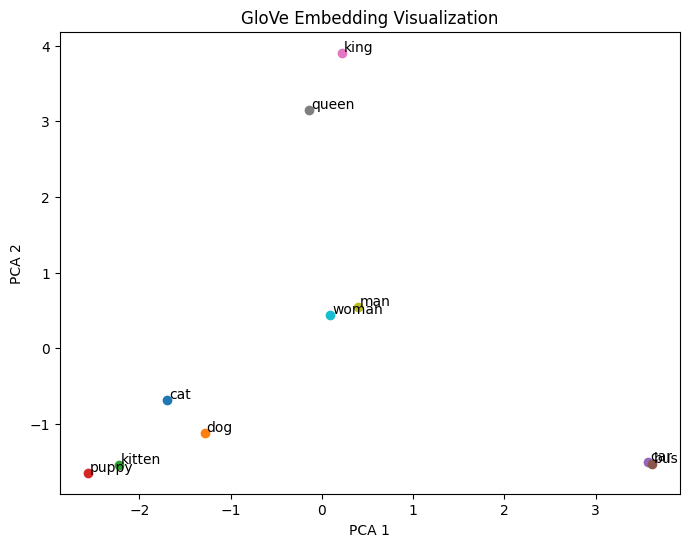

In [15]:
# 2차원 시각화하기
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for i, word in enumerate(valid_words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=10)

plt.title("GloVe Embedding Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

GloVe 모델 로드 중...
GloVe 로드 완료

Word2Vec 학습 중...
Word2Vec 학습 완료

===== GloVe 기본 정보 =====
벡터 차원: 50
단어 수: 400000

===== Word2Vec 기본 정보 =====
벡터 차원: 50
단어 수: 39

===== GloVe: 'cat' 벡터 앞 10개 =====
[ 0.45281  -0.50108  -0.53714  -0.015697  0.22191   0.54602  -0.67301
 -0.6891    0.63493  -0.19726 ]

===== Word2Vec: 'cat' 벡터 앞 10개 =====
[ 0.00776173 -0.01694099 -0.03191141  0.01596839  0.01050857 -0.03049322
 -0.02071261  0.03034037 -0.03543839  0.00945737]

===== GloVe: 단어 유사도 비교 =====
       cat <-> dog        : 0.9218
       cat <-> car        : 0.3638
      king <-> queen      : 0.7839
       man <-> woman      : 0.8860
     apple <-> orange     : 0.5388
       car <-> bus        : 0.8211

===== Word2Vec: 단어 유사도 비교 =====
       cat <-> dog        : 0.9310
       cat <-> car        : 0.8760
      king <-> queen      : 0.8625
       man <-> woman      : 0.7772
     apple <-> orange     : 0.8913
       car <-> bus        : 0.8345

===== GloVe: 'cat'와 비슷한 단어 =====
dog             0.9218
rabbi

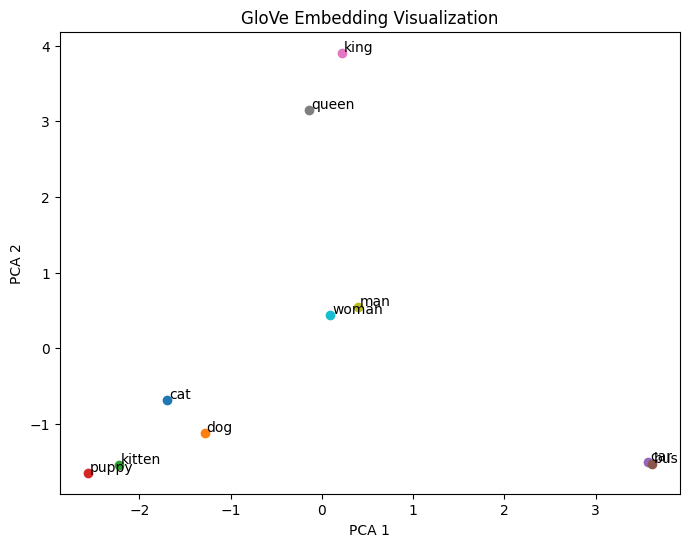

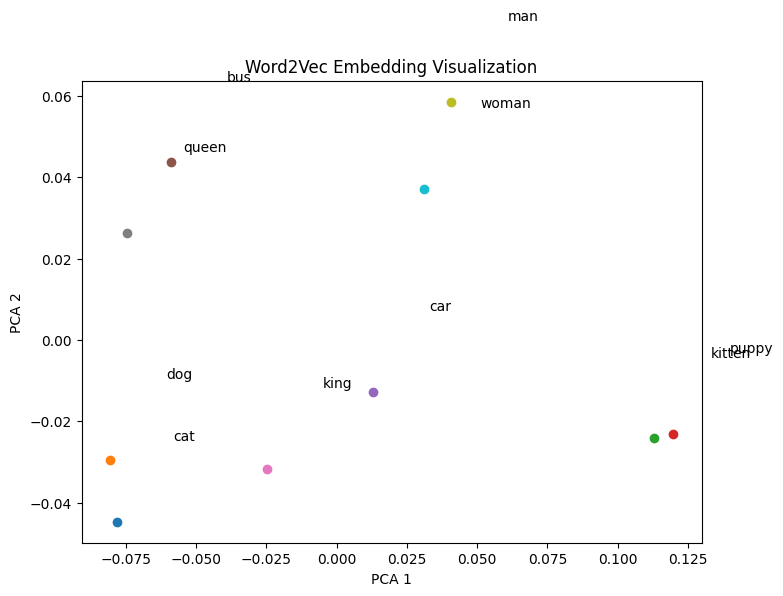

===== 간단 해석 가이드 =====
1. GloVe는 사전학습된 대규모 임베딩이라 결과가 더 안정적일 가능성이 큽니다.
2. 현재 Word2Vec은 작은 실습용 말뭉치로 학습했기 때문에 결과가 단순하고 제한적일 수 있습니다.
3. 그래도 구조는 같습니다:
   - model[word]      : 단어 벡터
   - model.similarity : 단어 유사도
   - model.most_similar : 비슷한 단어
4. Word2Vec을 더 잘 비교하려면 더 큰 말뭉치로 학습해야 합니다.


In [16]:
import gensim.downloader as api
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# 1. GloVe 불러오기
# -----------------------------------
print("GloVe 모델 로드 중...")
glove_model = api.load("glove-wiki-gigaword-50")
print("GloVe 로드 완료")
print()

# -----------------------------------
# 2. Word2Vec 학습용 작은 말뭉치 준비
# -----------------------------------
# 실습용이라 아주 작은 예시 말뭉치입니다.
# 비교가 잘 보이도록 동물 / 왕실 / 음식 / 교통 관련 문장을 일부 넣었습니다.
sentences = [
    ["cat", "is", "a", "pet"],
    ["dog", "is", "a", "pet"],
    ["kitten", "is", "a", "young", "cat"],
    ["puppy", "is", "a", "young", "dog"],
    ["cats", "and", "dogs", "are", "animals"],
    ["cat", "and", "dog", "live", "with", "people"],
    ["king", "is", "a", "man"],
    ["queen", "is", "a", "woman"],
    ["prince", "is", "a", "young", "king"],
    ["princess", "is", "a", "young", "queen"],
    ["man", "and", "woman", "are", "people"],
    ["apple", "and", "orange", "are", "fruits"],
    ["banana", "is", "a", "fruit"],
    ["car", "and", "bus", "are", "vehicles"],
    ["train", "is", "a", "vehicle"],
    ["cat", "likes", "milk"],
    ["dog", "likes", "bone"],
    ["king", "and", "queen", "live", "in", "palace"],
    ["man", "drives", "car"],
    ["woman", "rides", "bus"],
]

# -----------------------------------
# 3. Word2Vec 학습
# -----------------------------------
print("Word2Vec 학습 중...")
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,          # 1이면 Skip-gram, 0이면 CBOW
    epochs=300,
    seed=42
)
print("Word2Vec 학습 완료")
print()

# Word2Vec의 실제 단어 벡터는 wv 안에 있음
w2v_vectors = w2v_model.wv

# -----------------------------------
# 4. 공통 함수 정의
# -----------------------------------
def print_basic_info(name, model):
    print(f"===== {name} 기본 정보 =====")
    print("벡터 차원:", model.vector_size)
    print("단어 수:", len(model))
    print()

def show_vector(model, model_name, word):
    print(f"===== {model_name}: '{word}' 벡터 앞 10개 =====")
    if word in model:
        print(model[word][:10])
    else:
        print(f"'{word}' 가 vocabulary에 없습니다.")
    print()

def compare_similarity(model, model_name, pairs):
    print(f"===== {model_name}: 단어 유사도 비교 =====")
    for w1, w2 in pairs:
        if w1 in model and w2 in model:
            sim = model.similarity(w1, w2)
            print(f"{w1:>10} <-> {w2:<10} : {sim:.4f}")
        else:
            print(f"{w1}, {w2} 중 없는 단어가 있습니다.")
    print()

def show_most_similar(model, model_name, word, topn=5):
    print(f"===== {model_name}: '{word}'와 비슷한 단어 =====")
    if word in model:
        for sim_word, score in model.most_similar(word, topn=topn):
            print(f"{sim_word:<15} {score:.4f}")
    else:
        print(f"'{word}' 가 vocabulary에 없습니다.")
    print()

def show_analogy(model, model_name, positive, negative, topn=5):
    print(f"===== {model_name}: analogy =====")
    print("positive =", positive, ", negative =", negative)
    missing = [w for w in positive + negative if w not in model]
    if missing:
        print("없는 단어:", missing)
    else:
        for word, score in model.most_similar(positive=positive, negative=negative, topn=topn):
            print(f"{word:<15} {score:.4f}")
    print()

def plot_embeddings(models_info, words):
    """
    models_info = [
        ("GloVe", glove_model),
        ("Word2Vec", w2v_vectors)
    ]
    """
    for model_name, model in models_info:
        vectors = []
        valid_words = []

        for word in words:
            if word in model:
                vectors.append(model[word])
                valid_words.append(word)

        if len(vectors) < 2:
            print(f"{model_name}: 시각화 가능한 단어가 부족합니다.")
            continue

        pca = PCA(n_components=2)
        reduced = pca.fit_transform(vectors)

        plt.figure(figsize=(8, 6))
        for i, word in enumerate(valid_words):
            x, y = reduced[i]
            plt.scatter(x, y)
            plt.text(x + 0.02, y + 0.02, word, fontsize=10)

        plt.title(f"{model_name} Embedding Visualization")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.show()

# -----------------------------------
# 5. 기본 정보 확인
# -----------------------------------
print_basic_info("GloVe", glove_model)
print_basic_info("Word2Vec", w2v_vectors)

# -----------------------------------
# 6. 특정 단어 벡터 보기
# -----------------------------------
show_vector(glove_model, "GloVe", "cat")
show_vector(w2v_vectors, "Word2Vec", "cat")

# -----------------------------------
# 7. 단어 유사도 비교
# -----------------------------------
pairs = [
    ("cat", "dog"),
    ("cat", "car"),
    ("king", "queen"),
    ("man", "woman"),
    ("apple", "orange"),
    ("car", "bus"),
]

compare_similarity(glove_model, "GloVe", pairs)
compare_similarity(w2v_vectors, "Word2Vec", pairs)

# -----------------------------------
# 8. 비슷한 단어 찾기
# -----------------------------------
test_words = ["cat", "king", "car"]

for word in test_words:
    show_most_similar(glove_model, "GloVe", word, topn=5)
    show_most_similar(w2v_vectors, "Word2Vec", word, topn=5)

# -----------------------------------
# 9. 벡터 연산(analogy)
# -----------------------------------
# king - man + woman
show_analogy(glove_model, "GloVe", positive=["king", "woman"], negative=["man"], topn=5)
show_analogy(w2v_vectors, "Word2Vec", positive=["king", "woman"], negative=["man"], topn=5)

# -----------------------------------
# 10. 2차원 시각화
# -----------------------------------
plot_words = ["cat", "dog", "kitten", "puppy", "car", "bus", "king", "queen", "man", "woman"]
plot_embeddings(
    [
        ("GloVe", glove_model),
        ("Word2Vec", w2v_vectors)
    ],
    plot_words
)

# -----------------------------------
# 11. 모델 차이 한 번에 요약 출력
# -----------------------------------
print("===== 간단 해석 가이드 =====")
print("1. GloVe는 사전학습된 대규모 임베딩이라 결과가 더 안정적일 가능성이 큽니다.")
print("2. 현재 Word2Vec은 작은 실습용 말뭉치로 학습했기 때문에 결과가 단순하고 제한적일 수 있습니다.")
print("3. 그래도 구조는 같습니다:")
print("   - model[word]      : 단어 벡터")
print("   - model.similarity : 단어 유사도")
print("   - model.most_similar : 비슷한 단어")
print("4. Word2Vec을 더 잘 비교하려면 더 큰 말뭉치로 학습해야 합니다.")

# FastText

FastText는 **단어를 벡터(숫자)** 로 바꾸는 임베딩 방법.  
특히 **단어 전체만 보는 것이 아니라, 단어를 이루는 문자 조각(subword)** 까지 함께 사용한다는 점이 핵심.

---

## 1. 왜 필요한가?

Word2Vec은 단어를 통째로 하나씩 학습.

예:
- `play`
- `player`
- `playing`

이 단어들은 서로 비슷하지만, Word2Vec에서는 기본적으로 각각 다른 단어로 배웁니다.

그래서 문제가 생깁니다.

- 형태가 비슷한 단어 관계를 충분히 반영하지 못할 수 있음
- 처음 보는 단어(OOV)에 약함

---

## 2. FastText의 핵심 아이디어

FastText는 단어를 **문자 n-gram**으로 나누어 학습.

예를 들어 `apple`을 보면:

- `app`
- `ppl`
- `ple`

같은 작은 조각들도 함께 사용합니다.

즉,

**단어 벡터 = 단어 내부 조각들의 정보까지 반영한 벡터**

라고 볼 수 있습니다.

---

## 3. Word2Vec과 차이

## Word2Vec
- 단어를 통째로 봄
- OOV 처리 약함
- 형태가 비슷한 단어 관계 반영이 약할 수 있음

## FastText
- 단어를 문자 조각까지 나누어 봄
- OOV 처리에 더 강함
- 형태가 비슷한 단어를 더 잘 반영할 수 있음

---

## 4. 장점

- 처음 보는 단어에도 어느 정도 대응 가능
- 희귀 단어 처리에 더 유리
- 형태가 비슷한 단어를 더 잘 학습
- 한국어처럼 형태 변화가 있는 언어에도 도움이 될 수 있음

---

## 5. 한계

- 여전히 **정적 임베딩**임
- 문맥에 따라 단어 뜻이 달라지는 것은 잘 반영하지 못함

예:
- `bank` = 은행
- `bank` = 강둑

FastText도 기본적으로는 같은 단어에 하나의 벡터를 주는 방식입니다.

---

## 6. Word2Vec, GloVe, FastText 비교

| 모델 | 핵심 방식 | 특징 |
|------|------|------|
| Word2Vec | 주변 단어 예측 | 단순하고 고전적 |
| GloVe | 전체 공기 통계 사용 | 전역 통계 반영 |
| FastText | subword 사용 | 형태 정보, OOV에 강함 |

---

## 7. 한국어에서 의미

한국어는 조사, 어미 변화가 많아서  
단어 형태가 자주 바뀝니다.

예:
- 학교
- 학교에
- 학교에서
- 학교를

FastText는 이런 단어들의 **형태적 유사성**을 일부 반영할 수 있어서  
Word2Vec보다 유리할 수 있습니다.

## <수식 정리>

- FastText는 **단어를 하나의 벡터로만 보지 않고, 그 단어를 이루는 문자 n-gram들의 벡터를 함께 사용하는 임베딩 방법**.
- **단어 벡터 = 단어 내부 부분 문자열(subword) 벡터들의 합**으로 표현


보통 단어의 시작과 끝을 표시하기 위해 `<`, `>`를 붙입니다.

- `where` → `<where>`

여기서 3-gram을 만들면 예를 들어:

- `<wh`
- `whe`
- `her`
- `ere`
- `re>`

이런 식으로 나눌 수 있습니다.

---

## 9. 단어 벡터 수식

FastText에서는 어떤 단어 $w $의 벡터를  
그 단어에 속한 **문자 n-gram 집합** $ G_w $의 벡터 합으로 표현합니다.

$$
\mathbf{z}_w = \sum_{g \in G_w} \mathbf{z}_g
$$

### 뜻
- $ w $: 하나의 단어
- $ G_w $: 단어 \( w \)에서 추출한 모든 문자 n-gram 집합
- $ g $: 그 중 하나의 n-gram
- $ \mathbf{z}_g $: n-gram \( g \)의 벡터
- $ \mathbf{z}_w $: 최종 단어 벡터

**단어 벡터 = 그 단어를 이루는 subword 벡터들의 합**

---

## 10. Skip-gram 방식에서의 점수 함수

FastText는 Word2Vec의 **Skip-gram** 구조를 확장한 방식으로 자주 설명됨.

중심 단어 $ w $가 주변 단어 $ c $를 예측할 때 점수(score)는 보통 다음처럼 둠.

$$
s(w, c) = \sum_{g \in G_w} \mathbf{z}_g^\top \mathbf{v}_c
$$

### 뜻
- $ s(w, c) $: 중심 단어 $ w $와 주변 단어 $ c $의 관련성 점수
- $ G_w $: 중심 단어 $ w $의 n-gram 집합
- $ \mathbf{z}_g $: n-gram $ g $의 입력 벡터
- $ \mathbf{v}_c $: 주변 단어 $ c $의 출력 벡터
- $ \mathbf{z}_g^\top \mathbf{v}_c $: 두 벡터의 내적

중심 단어 \( w \)를 직접 하나의 벡터로 보는 대신, **그 단어를 이루는 여러 n-gram 벡터를 모두 더해서 주변 단어와의 점수를 계산**.

---

## 11. 확률 표현

주변 단어 $ c $가 중심 단어 $ w $로부터 나올 확률은 softmax로 표현할 수 있습니다.

$$
p(c \mid w) = \frac{\exp\left( \sum_{g \in G_w} \mathbf{z}_g^\top \mathbf{v}_c \right)}
{\sum_{c' \in V} \exp\left( \sum_{g \in G_w} \mathbf{z}_g^\top \mathbf{v}_{c'} \right)}
$$
- $ p(c \mid w) $: 중심 단어 $ w $가 주어졌을 때 주변 단어 $ c $가 나올 확률
- $ V $: 전체 단어 집합(어휘집합)
- 분자: 실제 주변 단어 $ c $와의 점수
- 분모: 전체 단어들에 대한 점수를 모두 더한 값

---

## 12. 목적 함수

FastText도 Word2Vec과 비슷하게  
실제 주변 단어가 높은 확률을 갖도록 학습합니다.

전체 목적 함수는 보통 로그우도 최대화 형태로 씁니다.

$$
\sum_{t=1}^{T} \sum_{c \in C_t} \log p(c \mid w_t)
$$

- $ T $: 전체 학습 데이터에서 중심 단어 위치 수
- $ w_t $: $ t $번째 중심 단어
- $ C_t $: 그 중심 단어 주변의 문맥 단어 집합
- $ p(c \mid w_t) $: 중심 단어로부터 주변 단어가 나올 확률

**실제 문맥 단어가 잘 예측되도록 n-gram 벡터들을 학습하는 것**입니다.

---

## 13. 네거티브 샘플링 형태

실제로는 softmax 계산이 비싸기 때문에 보통 **negative sampling**을 사용합니다.

한 쌍의 중심 단어 \( w \), 주변 단어 \( c \)에 대해 목적 함수는 대략 다음처럼 씁니다.

$$
\log \sigma \left( \sum_{g \in G_w} \mathbf{z}_g^\top \mathbf{v}_c \right)
+ \sum_{n \in \mathcal{N}_{w,c}} \log \sigma \left( - \sum_{g \in G_w} \mathbf{z}_g^\top \mathbf{v}_n \right)
$$

- $ \sigma(x) = \frac{1}{1 + e^{-x}} $: sigmoid 함수
- $ \mathcal{N}_{w,c} $: negative sample 집합
- 첫 번째 항: 실제 주변 단어 $ c $와는 점수가 커지도록
- 두 번째 항: 가짜 주변 단어 $ n $들과는 점수가 작아지도록


- 진짜 문맥 단어는 가깝게
- 가짜 문맥 단어는 멀게

학습합니다.

---

### fastText 패키지를 사용 안하고 하는 코드 작성

In [ ]:
#1. 단어를 subword로 직접 확인
def make_ngrams(word, min_n=3, max_n=4):
    """
    fasttext처럼 단어 단위에 <, >를 붙인 뒤, character n-gram 함수를 만들어보자.
    """
    word = "<" + word + ">"     # fasttext는 단어의 시작"<"과 끝">"을 구분한다.
    ngrams = []                 # ngram을 저장

    for n in range(min_n, max_n +1):        # n=3,4 / n길이를 min_n부터 max_n까지 하나씩 증가하면서 반복
        for i in range(len(word) - n +1):   # 길이가 n인 문자열을 왼쪽부터 하나씩 잘라냄
            piece = word[i:i+n]             # i번째 위치부터 길이 n 만큼 잘라서 subword 생성
            ngrams.append(piece)            # 만든 조각을 리스트에 추가
    return ngrams                           # 최종적으로 만들어진 모든 n-gram 반환

word = 'apple'

ngrams = make_ngrams(word)                  # apple을 subword 조각들로 나누기
print('원래 단어: ', word)
print('생성된 subwords들: ')
for g in ngrams:
    print(g)

#fasttext
## 단어를 통째로 보지 않고, 단어 내부를 여러 조각으로 나눔.

원래 단어:  apple
생성된 subwords들: 
<ap
app
ppl
ple
le>
<app
appl
pple
ple>


In [ ]:
import numpy as np
# subword 벡터를 평균내서 단어 벡터를 만듦.
# 각 subword에 벡터를 부여하고 그 벡터들을 평균을 내서 단위 벡터를 만듦.

def create_subword_vectors(subwords, dim=5, seed=42):
    np.random.seed(42)
    # 왜 랜덤으로 할까? 재현성(Reproducibility) 때문에,
    # 동일한 수학 공식에 동일한 시드값을 넣으면, 컴퓨터는 언제, 어디서, 몇 번을 실행하든 100% 동일한 난수 순서를 뱉어냅니다.
    # 딥러닝과 AI 모델을 학습시킬 때 이 재현성은 실험의 성패를 가릅니다.
     
    subword_vectors = {}

    # 각 subword마다 dim차원 랜덤 벡터 생성
    for subword in subwords:
        subword_vectors[subword] = np.random.randn(dim)
    return subword_vectors

def make_word_vector(subwords, subword_vectors):   # subword 벡터들을 평균내어 단어 벡터를 만드는 함수
    
    vectors = [subword_vectors[subword] for subword in subwords]
    word_vector = np.mean(vectors, axis=0)    # axis=0: 같은 위치끼리 평균을 내서 하나의 벡터를 만듦.
    return word_vector

def show_word_vector_process(word, min_n=3,max_n=4,dim=5,seed=42):  # 전체 과정을 보여주는 함수
    # 1. 단어를 subword로 분해
    subwords = make_ngrams(word, min_n = min_n, max_n = max_n)

    # 2. 각 subword에 벡터 부여
    subword_vectors = create_subword_vectors(subwords, dim=dim, seed=42)

    # 3. subword 벡터 평균 -> 단위 벡터
    word_vector = make_word_vector(subwords, subword_vectors)
    print('원래 단어', word)
    print("\n생성된 subwords들:")
    for subword in subwords:
        print(subword)

    print("\n각 subwords의 벡터")
    for subword, vector in subword_vectors.items():
        print(f"{subword:5s} -> {vector}")
    print("\n최종 벡터 단어 평균:")
    print(word_vector)
show_word_vector_process("apple")
    

원래 단어 apple

생성된 subwords들:
<ap
app
ppl
ple
le>
<app
appl
pple
ple>

각 subwords의 벡터
<ap   -> [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
app   -> [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
ppl   -> [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
ple   -> [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
le>   -> [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]
<app  -> [ 0.11092259 -1.15099358  0.37569802 -0.60063869 -0.29169375]
appl  -> [-0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491]
pple  -> [-1.22084365  0.2088636  -1.95967012 -1.32818605  0.19686124]
ple>  -> [ 0.73846658  0.17136828 -0.11564828 -0.3011037  -1.47852199]

최종 벡터 단어 평균:
[-0.03007115  0.09090309  0.03619372 -0.72001516 -0.45822302]


## 두 단어의 subword 겹침 비교
## 공통으로 등장하는 subword -> 공통 개수를 확인

In [13]:
def get_subword_set(word, min_n=3, max_n=4):
    return set(make_ngrams(word, min_n, max_n))

def compare_subwords(word1, word2, min_n=3, max_n=4):

    subwords1 = get_subword_set(word1, min_n=min_n, max_n=max_n)
    subwords2 = get_subword_set(word2, min_n=min_n, max_n=max_n)

    commom_subwords = subwords1.intersection(subwords2) #intersection: 교집합

    return subwords1, subwords2, commom_subwords

# 두 단어를 subword 겹침 비교 결과를 출력하는 함수
def show_subword_overlap(word1, word2, min_n=3,max_n=4):

    subwords1, subwords2, commom_subwords = compare_subwords(word1,word2, min_n=min_n, max_n=max_n)

    print("첫 번째 단어: ", word1)
    print("두 번째 단어: ", word2)

    print("\n첫 번째 단어의 subword: ")
    print(sorted(subwords1))

    print("두 번째 단어의 subword: ")
    print(sorted(subwords2))

    print("\n공통 subword: ")
    print(sorted(commom_subwords))
    print("공통 subword의 갯수: ", len(commom_subwords))
show_subword_overlap("apple", "apples")

    

첫 번째 단어:  apple
두 번째 단어:  apples

첫 번째 단어의 subword: 
['<ap', '<app', 'app', 'appl', 'le>', 'ple', 'ple>', 'ppl', 'pple']
두 번째 단어의 subword: 
['<ap', '<app', 'app', 'appl', 'es>', 'les', 'les>', 'ple', 'ples', 'ppl', 'pple']

공통 subword: 
['<ap', '<app', 'app', 'appl', 'ple', 'ppl', 'pple']
공통 subword의 갯수:  7


In [ ]:
%pip install fasttext-wheel

In [7]:
# 단어 임베딩
## 학습용 텍스트 만들기
texts = [
    "apple banana fruit",
    "apple orange fruit",
    "banana orange fruit",
    "cat dog animal",
    "dog tiger animal",
    "cat tiger animal",
    "apple is sweet",
    "banana is yellow",
    "orange is juicy",
    "cat says meow",
    "dog says bark"
]

with open("data.txt", "w", encoding="utf-8") as f:
    for line in texts:
        f.write(line + "\n")

In [4]:
import fasttext

model = fasttext.train_unsupervised(       #비지도학습 기반
    "data.txt",
    model="skipgram",   # 또는 "cbow"
    dim=50,             # 임베딩 차원
    epoch=50,           # 학습 반복 수
    minn=2,             # 문자 n-gram 길이 범위
    maxn=4              # 문자 n-gram 길이 범위
)

In [5]:
# 단어 벡터 확인
print(model.get_word_vector("apple"))
print(len(model.get_word_vector("apple")))

[-2.7186370e-03  3.6137381e-03 -2.7003516e-03 -2.6076562e-03
 -4.8362659e-03  7.1001118e-03 -2.5048605e-05  1.5840275e-03
 -7.8598142e-04 -1.0088757e-03  1.4790915e-03 -4.4633490e-03
 -4.5503117e-03  6.8611483e-04 -1.6952608e-03  1.0770339e-03
 -1.5068641e-03  3.7932274e-05 -9.5482059e-03  3.6577063e-03
  1.6717343e-03  6.7653757e-04 -2.2806888e-03 -3.8526050e-04
  2.1932132e-03  7.0904209e-03 -2.0269698e-03  2.0885936e-03
 -4.8335525e-03  5.3190981e-04  1.0791499e-03 -1.6143293e-03
 -1.6368766e-03 -5.4138410e-03 -8.6732174e-04  6.8606585e-03
 -1.2587297e-03  1.0584934e-03 -1.7571272e-03 -2.8569342e-03
  2.3393328e-03  3.6160804e-03 -1.0634926e-03  1.7583862e-04
 -3.2246104e-03  1.5783646e-03  7.2023584e-05  4.8419787e-03
 -3.7066450e-03 -2.1168129e-03]
50


In [ ]:
# 학습에 없던 단어도 벡터 확인
## FastText의 중요한 장점은 학습 데이터에 없던 단어도 subword 기반으로 벡터를 만들 수 있음.
print(model.get_word_vector("apples"))
print(model.get_word_vector("doggy"))
# Word2Vec은 보통 이런 OOV 단어 처리에 약하지만, FastText는 상대적으로 강함.

In [ ]:
# 저장하고 불러오기
model.save_model("fasttext_model.bin")

loaded_model = fasttext.load_model("fasttext_model.bin")
print(loaded_model.get_nearest_neighbors("banana"))

In [ ]:
# 한국어 예제로 해보기
korean_texts = [
    "사과 바나나 과일",
    "사과 오렌지 과일",
    "바나나 오렌지 과일",
    "고양이 강아지 동물",
    "강아지 호랑이 동물",
    "고양이 호랑이 동물",
    "사과는 달다",
    "바나나는 노랗다",
    "오렌지는 상큼하다",
    "고양이는 야옹",
    "강아지는 멍멍"
]

with open("korean_data.txt", "w", encoding="utf-8") as f:
    for line in korean_texts:
        f.write(line + "\n")

import fasttext

ko_model = fasttext.train_unsupervised(
    "korean_data.txt",
    model="skipgram",
    dim=50,
    epoch=100,
    minn=2,
    maxn=4
)

print(ko_model.get_nearest_neighbors("사과"))
print(ko_model.get_nearest_neighbors("고양이"))
print(ko_model.get_word_vector("사과들"))   # 학습에 없던 단어 예시

In [ ]:
# 문장 벡터를 간단히 만드는 방법
##FastText는 기본적으로 단어 벡터 모델 -> 문장에 있는 단어 벡터 평균으로 간단히 만들 수 있음.
import numpy as np

def sentence_vector(sentence, model):
    words = sentence.split()
    vectors = [model.get_word_vector(word) for word in words]
    return np.mean(vectors, axis=0)

vec1 = sentence_vector("사과 바나나 과일", ko_model)
vec2 = sentence_vector("고양이 강아지 동물", ko_model)

print(vec1.shape)
print(vec2.shape)

In [ ]:
# 두 문장의 유사도 계산
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

s1 = sentence_vector("사과 오렌지 과일", ko_model)
s2 = sentence_vector("바나나 사과 과일", ko_model)
s3 = sentence_vector("고양이 호랑이 동물", ko_model)

print("문장1-문장2 유사도:", cosine_similarity(s1, s2))
print("문장1-문장3 유사도:", cosine_similarity(s1, s3))

In [ ]:
# 분류 실습하기
train_data = [
    "__label__fruit 사과 바나나 오렌지",
    "__label__fruit 바나나 사과 과일",
    "__label__fruit 오렌지 과일 달다",
    "__label__animal 고양이 강아지 호랑이",
    "__label__animal 강아지 동물 멍멍",
    "__label__animal 고양이 동물 야옹"
]

with open("train_classification.txt", "w", encoding="utf-8") as f:
    for line in train_data:
        f.write(line + "\n")

In [ ]:
# 분류 모델 학습
classifier = fasttext.train_supervised(
    "train_classification.txt",
    epoch=50,
    lr=1.0,
    wordNgrams=2
)

In [ ]:
#예측
print(classifier.predict("사과 오렌지"))
print(classifier.predict("고양이 강아지"))
# Numpy가 2이상이라, fasttext가 지원을 하지 않음. -> 1.X로 낮춰야 가능 (권장하지 않음)

## 1. ELMo(Embeddings from Language Models)란?

**문맥을 반영해서 같은 단어라도 다른 벡터로 표현하는 임베딩 방법**

단어 하나에 벡터 하나를 고정하는 것이 아니라, **문장 안에서 그 단어가 어떤 의미로 쓰였는지**에 따라 벡터가 달라짐.

예를 들어, `bank`라는 단어는

- `I deposited money in the bank.` → **은행**
- `He sat on the bank of the river.` → **강둑**

처럼 문맥에 따라 다른 임베딩을 가짐.

---

## 2. 아이디어

ELMo는 **양방향 언어모델(Bidirectional Language Model, biLM)**의  
각 층(hidden state)에서 나온 표현을 조합해서 단어 벡터를 만듭니다.


- **앞에서 뒤로 읽는 LM**
- **뒤에서 앞으로 읽는 LM**

을 함께 사용해서 단어의 **왼쪽 문맥 + 오른쪽 문맥**을 모두 반영합니다.

---

## 3. 언어모델의 확률식

문장 $(t_1, t_2, \dots, t_N)$ 이 있을 때, 정방향 언어모델은 다음 확률을 모델링함.

$$
p(t_1, t_2, \dots, t_N)
= \prod_{k=1}^{N} p(t_k \mid t_1, \dots, t_{k-1})
$$

현재 단어 \(t_k\)를 이전 단어들 \(t_1, \dots, t_{k-1}\)을 보고 예측.

---

반대로 역방향 언어모델은

$$
p(t_1, t_2, \dots, t_N)
= \prod_{k=1}^{N} p(t_k \mid t_{k+1}, \dots, t_N)
$$

처럼 미래 단어들을 보고 현재 단어를 예측.

---

## 4. biLM의 구조

ELMo는 정방향과 역방향 LSTM을 함께 사용합니다.

각 위치 $k$에서:

- 정방향 hidden state: $\overrightarrow{\mathbf{h}}_{k,j}$
- 역방향 hidden state: $\overleftarrow{\mathbf{h}}_{k,j}$

여기서 $j$는 층(layer) 번호.

각 층의 표현은 두 방향의 hidden state를 합쳐서 만듭니다.

$$
\mathbf{h}_{k,j}
=
\left[
\overrightarrow{\mathbf{h}}_{k,j}
;
\overleftarrow{\mathbf{h}}_{k,j}
\right]
$$

여기서 $[a;b]$는 **벡터 concatenation**입니다. 앞문맥 정보와 뒷문맥 정보를 이어 붙인 것입니다.

---

## 5. 입력층 표현

ELMo는 단어를 바로 one-hot으로 쓰지 않고,  
보통 **character-based CNN**을 통해 단어의 초기 표현을 만듭니다.

각 단어 $t_k$의 입력 표현을

$$
\mathbf{x}^{LM}_k
$$

라고 둡니다.

이 표현은 단어 철자 정보를 반영하므로,

- 희귀 단어
- 형태가 비슷한 단어
- 접두사/접미사가 중요한 단어

에 강점이 있음.

---

## 6. ELMo 최종 표현식

ELMo의 핵심 수식은 다음입니다.

$$
\text{ELMo}^{task}_k
=
\gamma^{task}
\sum_{j=0}^{L}
s^{task}_j \mathbf{h}_{k,j}^{LM}
$$

- $k$: 문장 안에서의 단어 위치
- $L$: biLM의 마지막 층 번호
- $\mathbf{h}_{k,j}^{LM}$: 단어 \(k\)의 \(j\)번째 층 표현
- $s_j^{task}$: 각 층에 대한 가중치
- $\gamma^{task}$: 전체 스케일 조정값

---

### (1) $\mathbf{h}_{k,j}^{LM}$

$$
\mathbf{h}_{k,j}^{LM}
$$

는 **언어모델의 각 층에서 얻은 단어 표현**.

- $j=0$: 입력층 표현
- $j=1,2,\dots,L$: 각 BiLSTM 층의 출력

하나의 단어에 대해 ELMo는 **한 개의 벡터만 쓰는 것이 아니라 여러 층의 표현을 모두 활용**.

---

### (2) $s_j^{task}$

$$
\sum_{j=0}^{L} s_j^{task} = 1
$$

이 되도록 보통 softmax로 정규화된 가중치.


태스크마다

- 어떤 층 정보가 더 중요한지
- 표면적인 정보가 중요한지
- 문맥적/의미적 정보가 중요한지

를 학습해서 결정.

예를 들어,

- 낮은 층: 문법, 형태 정보
- 높은 층: 문맥, 의미 정보

를 더 많이 담는 경향이 있음.

---

### (3) $\gamma^{task}$

$$
\gamma^{task}
$$

는 전체 벡터 크기를 조절하는 **학습 가능한 스칼라 값**.

여러 층을 가중합한 뒤 그 결과를 얼마나 크게 또는 작게 쓸지 조절.

---

## 8. 왜 층별 가중합을 쓰는가?

ELMo는 마지막 층만 사용하는 것이 아니라,  
모든 층의 표현을 가중합합니다.

그 이유는 각 층이 담는 정보가 다르기 때문.

- **하위층**: 철자, 형태, 문법
- **상위층**: 문맥, 의미

따라서 특정 태스크에서는 하위층이 더 중요할 수도 있고, 상위층이 더 중요할 수도 있습니다.

그래서 ELMo는

$$
\text{모든 층의 표현} \rightarrow \text{가중합}
$$

방식을 사용합니다.


In [ ]:
%pip install allennlp allennlp-models

In [ ]:
# ELMo 실습 예제
# 설치가 안 되어 있다면 먼저 실행


from allennlp.modules.elmo import Elmo, batch_to_ids
import torch

# 1. ELMo 옵션 파일과 가중치 파일 주소
options_file = "https://allennlp.s3.amazonaws.com/models/elmo/2x4096_512_2048cnn_2xhighway/elmo_2x4096_512_2048cnn_2xhighway_options.json"
weight_file = "https://allennlp.s3.amazonaws.com/models/elmo/2x4096_512_2048cnn_2xhighway/elmo_2x4096_512_2048cnn_2xhighway_weights.hdf5"

# 2. ELMo 모델 준비
# num_output_representations=1 이면 출력 1개만 사용
elmo = Elmo(options_file, weight_file, num_output_representations=1, dropout=0)

# 3. 문장 준비
sentences = [
    ["I", "love", "natural", "language", "processing", "."],
    ["The", "bank", "is", "by", "the", "river", "."],
    ["I", "went", "to", "the", "bank", "to", "save", "money", "."]
]

# 4. 문자 단위 ID로 변환
character_ids = batch_to_ids(sentences)

# 5. ELMo 통과
with torch.no_grad():
    embeddings = elmo(character_ids)

# 6. 출력 확인
# elmo_representations[0]의 shape:
# (문장 개수, 토큰 개수, 임베딩 차원)
elmo_embeddings = embeddings["elmo_representations"][0]

print("전체 임베딩 shape:", elmo_embeddings.shape)

# 7. 첫 번째 문장의 각 토큰 임베딩 크기 확인
print("첫 번째 문장 임베딩 shape:", elmo_embeddings[0].shape)

# 8. 첫 번째 문장의 토큰 출력
print("첫 번째 문장 토큰들:", sentences[0])

# 9. bank 단어 벡터 비교
bank_vec_1 = elmo_embeddings[1][1]   # "bank" in river sentence
bank_vec_2 = elmo_embeddings[2][4]   # "bank" in money sentence

print("\n두 bank 벡터의 앞 10개 값 비교")
print("river 문맥의 bank:", bank_vec_1[:10])
print("money 문맥의 bank:", bank_vec_2[:10])

# 10. 두 bank 벡터 차이 확인
difference = torch.norm(bank_vec_1 - bank_vec_2).item()
print("\n두 bank 벡터 거리:", difference)

# BERT

BERT는 **문맥을 반영하는 임베딩 모델**.  
같은 단어라도 문장 속에서 의미가 다르면 **다른 벡터**로 표현할 수 있음.

예:
- *bank* = 은행
- *bank* = 강둑

핵심:
- 문맥을 반영함
- 보통 **토큰별 벡터**를 만듦
- 문장 전체 임베딩에 바로 최적화된 모델은 아님

**BERT는 문맥 임베딩을 이해하기 위한 기본 모델입니다.**


In [ ]:
# 설치가 안 되어 있다면 먼저 실행
# !pip install transformers torch

from transformers import AutoTokenizer, AutoModel
import torch

# 1. BERT 토크나이저와 모델 불러오기
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# 2. 실습할 문장 준비
sentences = [
    "I love natural language processing.",
    "BERT creates contextual embeddings."
]

# 3. 문장을 토큰화
inputs = tokenizer(
    sentences,
    padding=True,      # 길이를 맞춤
    truncation=True,   # 너무 길면 자름
    return_tensors="pt"  # 파이토치 텐서로 반환
)

# 4. BERT 통과
with torch.no_grad():
    outputs = model(**inputs)

# 5. 결과 확인
last_hidden_state = outputs.last_hidden_state

print("last_hidden_state shape:", last_hidden_state.shape)
# (문장 개수, 토큰 개수, hidden size)

# 6. 첫 번째 문장의 토큰들 확인
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("\n첫 번째 문장의 토큰들:")
print(tokens)

# 7. 첫 번째 문장의 각 토큰 임베딩 크기 확인
print("\n첫 번째 문장의 토큰 임베딩 shape:")
print(last_hidden_state[0].shape)
# (토큰 개수, hidden size)

# 8. [CLS] 벡터를 문장 임베딩처럼 사용
cls_embedding = last_hidden_state[:, 0, :]
print("\n[CLS] 임베딩 shape:")
print(cls_embedding.shape)
# (문장 개수, hidden size)

# 9. mean pooling으로 문장 임베딩 만들기
attention_mask = inputs["attention_mask"]

# padding 부분 제외하고 평균내기
mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
sum_embeddings = torch.sum(last_hidden_state * mask, dim=1)
sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
mean_pooled = sum_embeddings / sum_mask

print("\nMean Pooling 임베딩 shape:")
print(mean_pooled.shape)
# (문장 개수, hidden size)

# 10. 실제 벡터 일부 출력
print("\n첫 번째 문장의 [CLS] 벡터 앞 10개 값:")
print(cls_embedding[0][:10])

print("\n첫 번째 문장의 Mean Pooling 벡터 앞 10개 값:")
print(mean_pooled[0][:10])

In [ ]:
# 토큰별 임베딩 확인
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sentence = "I love BERT."
inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("토큰들:", tokens)
print("출력 shape:", outputs.last_hidden_state.shape)

In [ ]:
# 두 문장 유사도 구하기
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sentences = [
    "I like apples.",
    "I enjoy apples."
]

inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

last_hidden_state = outputs.last_hidden_state
attention_mask = inputs["attention_mask"]

mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
sum_embeddings = torch.sum(last_hidden_state * mask, dim=1)
sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
sentence_embeddings = sum_embeddings / sum_mask

similarity = F.cosine_similarity(
    sentence_embeddings[0].unsqueeze(0),
    sentence_embeddings[1].unsqueeze(0)
)

print("문장 유사도:", similarity.item())

In [ ]:
#한국어 예제
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

sentence = "나는 BERT 임베딩을 공부하고 있다."
inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("토큰들:", tokens)
print("출력 shape:", outputs.last_hidden_state.shape)
print("CLS 벡터 크기:", outputs.last_hidden_state[:, 0, :].shape)

# SBERT

이들은 **문장 전체를 하나의 벡터로 잘 표현하는 모델**.  
특히 **문장 유사도 비교**와 **검색**에 많이 사용됨.

## SBERT
BERT를 문장 임베딩에 맞게 바꾼 모델.  
문장끼리 코사인 유사도를 쉽게 비교할 수 있음.

핵심:
- 문장 유사도에 강함
- 문장 분류, 군집화, 중복 탐지에 적합

  
**문장 임베딩의 대표적인 기본 모델.**


In [ ]:
# 설치가 안 되어 있다면 먼저 실행
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer, util

# 1. SBERT 모델 불러오기
model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. 비교할 문장 준비
sentences = [
    "I like apples.",
    "I enjoy apples.",
    "The weather is very nice today."
]

# 3. 문장 임베딩 만들기
embeddings = model.encode(sentences, convert_to_tensor=True)

# 4. 임베딩 크기 확인
print("임베딩 shape:", embeddings.shape)

# 5. 문장끼리 유사도 계산
sim_1_2 = util.cos_sim(embeddings[0], embeddings[1])
sim_1_3 = util.cos_sim(embeddings[0], embeddings[2])

print("문장 1과 문장 2 유사도:", sim_1_2.item())
print("문장 1과 문장 3 유사도:", sim_1_3.item())

In [ ]:
# 한국어 예제
# 설치가 안 되어 있다면 먼저 실행
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

sentences = [
    "나는 사과를 좋아한다.",
    "나는 사과 먹는 것을 좋아한다.",
    "오늘 날씨가 정말 좋다."
]

embeddings = model.encode(sentences, convert_to_tensor=True)

sim_1_2 = util.cos_sim(embeddings[0], embeddings[1])
sim_1_3 = util.cos_sim(embeddings[0], embeddings[2])

print("문장 1과 문장 2 유사도:", sim_1_2.item())
print("문장 1과 문장 3 유사도:", sim_1_3.item())

In [ ]:
# 간단한 검색 예제
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

query = "과일을 좋아해"
documents = [
    "나는 사과를 좋아한다.",
    "나는 축구를 좋아한다.",
    "오늘은 비가 온다."
]

query_embedding = model.encode(query, convert_to_tensor=True)
doc_embeddings = model.encode(documents, convert_to_tensor=True)

scores = util.cos_sim(query_embedding, doc_embeddings)[0]

for doc, score in zip(documents, scores):
    print(f"{doc} -> {score.item():.4f}")


## E5
검색에 강한 임베딩 모델입니다.  
질문과 문서를 잘 매칭하도록 학습되었습니다.

핵심:
- 검색, RAG, FAQ 검색에 적합
- query와 document를 잘 연결함


**검색 중심 임베딩 모델입니다.**

In [ ]:
# 설치가 안 되어 있다면 먼저 실행
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer, util

# 1. E5 모델 불러오기
# 영어 중심 예제
model = SentenceTransformer("intfloat/e5-base-v2")

# 2. E5는 보통 query:, passage: 접두어를 붙여서 사용
query = "query: What is a good fruit to eat in the morning?"
passages = [
    "passage: Apples are a healthy fruit that many people enjoy for breakfast.",
    "passage: Soccer is a popular sport played around the world.",
    "passage: Bananas are often eaten in the morning because they are convenient and nutritious."
]

# 3. 임베딩 만들기
query_embedding = model.encode(query, convert_to_tensor=True)
passage_embeddings = model.encode(passages, convert_to_tensor=True)

# 4. 코사인 유사도 계산
scores = util.cos_sim(query_embedding, passage_embeddings)[0]

# 5. 결과 출력
for passage, score in zip(passages, scores):
    print(f"{passage} -> {score.item():.4f}")



## BGE
최근 자주 쓰이는 검색용 임베딩 계열입니다.  
RAG와 문서 검색에서 많이 사용됩니다.

핵심:
- 검색 성능이 좋음
- 실전 활용도가 높음

한 줄 정리:  
**BGE는 최신 검색/RAG용 임베딩 모델입니다.**


In [ ]:
# 설치가 안 되어 있다면 먼저 실행
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch

# 1. BGE 모델 불러오기
# 영어 중심 모델 예시
model = SentenceTransformer("BAAI/bge-base-en-v1.5")

# 2. 검색용 문장 준비
# BGE는 query에 instruction을 붙여 쓰는 경우가 많음
query = "Represent this sentence for searching relevant passages: What is a healthy fruit for breakfast?"
documents = [
    "Apples are a healthy fruit often eaten in the morning.",
    "Basketball is a popular sport played by many people.",
    "Bananas are convenient and nutritious for breakfast."
]

# 3. 임베딩 만들기
query_embedding = model.encode(query, convert_to_tensor=True)
doc_embeddings = model.encode(documents, convert_to_tensor=True)

# 4. 유사도 계산
scores = util.cos_sim(query_embedding, doc_embeddings)[0]

# 5. 결과 출력
for doc, score in zip(documents, scores):
    print(f"{doc} -> {score.item():.4f}")


---

# NV-Embed / LLM2Vec

- SBERT/E5/BGE보다 훨씬 무겁고  GPU 메모리 요구량이 큰 편

이들은 **LLM을 임베딩 모델처럼 활용하는 최신 흐름**입니다.

예전에는 보통 BERT류 모델로 임베딩을 만들었지만,  
최근에는 **LLM도 좋은 임베딩 모델이 될 수 있다**는 방향으로 발전하고 있습니다.

## NV-Embed
LLM 기반의 최신 임베딩 모델입니다.

핵심:
- LLM을 임베딩에도 활용
- 최신 벤치마크에서 강한 성능

## LLM2Vec
LLM을 문장 표현용 모델처럼 사용할 수 있게 만든 접근입니다.

핵심:
- 생성 모델을 임베딩에도 활용
- 최신 연구 흐름 이해에 중요
**LLM 기반 임베딩의 최신 흐름입니다.**

- Colab 무료버전 OOM(26.03.23)

In [ ]:
# NV-Embed 실습 예제
# NV-Embed-v2 모델 카드는 질문(query)에는 instruction을 붙이고, 문서(passages)에는 보통 instruction 없이 임베딩
# 모델 접근이 제한될 수 있어 Hugging Face 인증이 필요할 수 있습니다.
# 설치 예시
# !pip install torch transformers sentence-transformers flash-attn

import torch
import torch.nn.functional as F
from transformers import AutoModel

# NV-Embed-v2는 restricted access일 수 있어서
# Hugging Face 로그인(huggingface-cli login)이 필요할 수 있음
model_name = "nvidia/NV-Embed-v2"

# 모델 로드
model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

# 검색용 instruction
task_instruction = "Given a question, retrieve passages that answer the question"
query_prefix = f"Instruct: {task_instruction}\nQuery: "
passage_prefix = ""

queries = [
    "What is a good fruit to eat in the morning?",
    "What is deep learning?"
]

passages = [
    "Apples and bananas are common breakfast fruits because they are convenient and nutritious.",
    "Deep learning is a machine learning method based on artificial neural networks.",
    "Soccer is a popular sport around the world."
]

# 임베딩 생성
# 모델 카드 예시처럼 model.encode(...) 사용
max_length = 512

query_embeddings = model.encode(
    queries,
    instruction=query_prefix,
    max_length=max_length
)

passage_embeddings = model.encode(
    passages,
    instruction=passage_prefix,
    max_length=max_length
)

# 텐서로 변환
query_embeddings = torch.tensor(query_embeddings)
passage_embeddings = torch.tensor(passage_embeddings)

# 정규화 후 코사인 유사도 계산
query_embeddings = F.normalize(query_embeddings, p=2, dim=1)
passage_embeddings = F.normalize(passage_embeddings, p=2, dim=1)

scores = torch.mm(query_embeddings, passage_embeddings.T)

print("유사도 행렬:")
print(scores)

# 각 query마다 가장 유사한 문서 찾기
for i, q in enumerate(queries):
    best_idx = torch.argmax(scores[i]).item()
    print(f"\n질문: {q}")
    print(f"가장 유사한 문서: {passages[best_idx]}")
    print(f"점수: {scores[i][best_idx].item():.4f}")

In [ ]:
#NV-Embed 더 간단한 1개 질의 검색 예제
import torch
import torch.nn.functional as F
from transformers import AutoModel

model = AutoModel.from_pretrained(
    "nvidia/NV-Embed-v2",
    trust_remote_code=True
)

query = ["machine learning basics"]
docs = [
    "Machine learning studies algorithms that learn from data.",
    "Pasta can be cooked with olive oil and garlic.",
    "Deep learning is a subfield of machine learning."
]

instruction = "Instruct: Given a question, retrieve passages that answer the question\nQuery: "

q_emb = torch.tensor(
    model.encode(query, instruction=instruction, max_length=256)
)
d_emb = torch.tensor(
    model.encode(docs, instruction="", max_length=256)
)

q_emb = F.normalize(q_emb, p=2, dim=1)
d_emb = F.normalize(d_emb, p=2, dim=1)

scores = torch.mm(q_emb, d_emb.T)[0]

for doc, score in zip(docs, scores):
    print(f"{score.item():.4f} | {doc}")

In [ ]:
#LLM2Vec 실습 예제
# 설치 예시
# !pip install llm2vec peft transformers torch

import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig
from peft import PeftModel
from llm2vec import LLM2Vec

model_name = "McGill-NLP/LLM2Vec-Mistral-7B-Instruct-v2-mntp"

# 1. 토크나이저와 설정 불러오기
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(
    model_name,
    trust_remote_code=True
)

# 2. base model 로드
model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True,
    config=config,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="cuda" if torch.cuda.is_available() else "cpu",
)

# 3. MNTP adapter 로드
model = PeftModel.from_pretrained(
    model,
    model_name
)

# 4. LLM2Vec 래퍼 생성
l2v = LLM2Vec(
    model,
    tokenizer,
    pooling_mode="mean",
    max_length=512
)

# 5. query는 instruction + text 형태
instruction = "Given a web search query, retrieve relevant passages that answer the query:"
queries = [
    [instruction, "What is a healthy fruit for breakfast?"],
    [instruction, "What is deep learning?"]
]

# 6. documents는 그냥 문자열
documents = [
    "Apples and bananas are healthy breakfast fruits.",
    "Deep learning is a machine learning method based on neural networks.",
    "Basketball is played by two teams on a court."
]

# 7. 임베딩 생성
q_reps = l2v.encode(queries)
d_reps = l2v.encode(documents)

# 8. 정규화 후 코사인 유사도
q_reps = torch.nn.functional.normalize(q_reps, p=2, dim=1)
d_reps = torch.nn.functional.normalize(d_reps, p=2, dim=1)

scores = torch.mm(q_reps, d_reps.transpose(0, 1))

print("유사도 행렬:")
print(scores)

for i, q in enumerate(queries):
    best_idx = torch.argmax(scores[i]).item()
    print(f"\n질문: {q[1]}")
    print(f"가장 유사한 문서: {documents[best_idx]}")
    print(f"점수: {scores[i][best_idx].item():.4f}")